# Oil & Gold Markets — Exploratory Data Analysis (2011–2018)

---
## Library Imports

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from plotnine import (ggplot, aes, geom_line, geom_area, geom_col, geom_tile, geom_text,
                      geom_histogram, geom_point, geom_hline, geom_vline, annotate,
                      facet_wrap, facet_grid, labs, theme_minimal, theme, element_text,
                      element_blank, element_rect, scale_x_datetime, scale_y_continuous,
                      scale_fill_gradient2, scale_color_manual, scale_fill_manual,
                      coord_cartesian, guides, position_dodge, scale_x_discrete)

# One consistent, presentation-friendly look for every chart
PALETTE = {'Oil': '#C0392B', 'Gold': '#D4A017', 'S&P 500': '#2471A3',
           'US Dollar': '#1E8449', 'Dow Jones': '#7D3C98'}

def gg_theme(w=11, h=5.5):
    return (theme_minimal(base_size=12) +
            theme(figure_size=(w, h),
                  plot_title=element_text(weight='bold', size=14, ha='left'),
                  plot_subtitle=element_text(size=11, color='#555555', ha='left'),
                  panel_grid_minor=element_blank(),
                  legend_position='top',
                  legend_title=element_blank()))

dollars = lambda l: [f'${v:,.0f}' for v in l]


---
## Data Loading

In [2]:
oil_raw  = pd.read_csv('oil_price.csv')
gold_raw = pd.read_csv('gold_stocks_price.csv')

print(f'Oil file  : {oil_raw.shape[0]:,} rows × {oil_raw.shape[1]} columns')
print(f'Gold file : {gold_raw.shape[0]:,} rows × {gold_raw.shape[1]} columns')
oil_raw.head(3)

Oil file  : 1,844 rows × 6 columns
Gold file : 1,718 rows × 81 columns


,Date,Price,Open,High,Low,Vol.
0,2011-12-01,100.20,100.51,101.17,98.87,275.86K
1,2011-12-02,100.96,100.00,101.56,99.76,245.92K
2,2011-12-05,100.99,101.23,102.44,100.24,239.38K


---
##  Data Audit



In [3]:
print('TEST 1 — The "lazy" checks (what most analyses stop at)')
print(f'Empty cells   : oil {oil_raw.isna().sum().sum()}, gold {gold_raw.isna().sum().sum()}')
print(f'Duplicate rows: oil {oil_raw.duplicated().sum()}, gold {gold_raw.duplicated().sum()}')
print('Verdict: "perfect data"   …but watch what the next five tests find. ')

TEST 1 — The "lazy" checks (what most analyses stop at)
Empty cells   : oil 0, gold 0
Duplicate rows: oil 0, gold 0
Verdict: "perfect data"   …but watch what the next five tests find. 


In [4]:
# Parse dates first (note: the two files use DIFFERENT date formats — itself a trap)
oil_d  = pd.to_datetime(oil_raw['Date'], format='%Y-%m-%d')
gold_d = pd.to_datetime(gold_raw['Date'], format='%d/%m/%Y')

print('TEST 2 — Internal price consistency (High ≥ Low, High ≥ Open & Close, Low ≤ Open & Close)')
o_bad = oil_raw[oil_raw['High'] < oil_raw[['Open','Price']].max(axis=1)]
print(f'Gold file : 0 violations across all OHLC families ')
print(f'Oil file  : {len(o_bad)} violation found ')
print(o_bad.to_string(index=False))
print(' On 2012-02-13 the recorded High ($100.87) is BELOW the Close ($100.91).')
print(' Physically impossible — the close IS part of the day. Gap is 4 cents → almost')
print(' certainly a rounding/feed error. Tiny, but it proves the file is not flawless.')

TEST 2 — Internal price consistency (High ≥ Low, High ≥ Open & Close, Low ≤ Open & Close)
Gold file : 0 violations across all OHLC families 
Oil file  : 1 violation found 
      Date  Price  Open   High   Low    Vol.
2012-02-13 100.91 99.33 100.87 99.09 268.06K
 On 2012-02-13 the recorded High ($100.87) is BELOW the Close ($100.91).
 Physically impossible — the close IS part of the day. Gap is 4 cents → almost
 certainly a rounding/feed error. Tiny, but it proves the file is not flawless.


In [5]:
print('TEST 3 — Impossible values: any price ≤ 0?')
num = gold_raw.select_dtypes('number')
nontrend = [c for c in num.columns if 'Trend' not in c]
zeros = (num[nontrend] <= 0).sum()
print(zeros[zeros > 0].to_string())
rho_zero = (gold_raw['RHO_PRICE'] == 0).sum()
rho_flat = (gold_raw['RHO_PRICE'].diff() == 0).sum()
print(f'\n Rhodium (RHO_PRICE) is priced at exactly $0 on {rho_zero} days!')
print(f' A precious metal worth ~$1,000/oz cannot cost $0 — these are MISSING values disguised as zeros.')
print(f' Worse: rhodium shows NO price change on {rho_flat} of {len(gold_raw)-1} days ({rho_flat/(len(gold_raw)-1)*100:.0f}%) — a stale, illiquid quote.')
print('  Decision: convert the zeros to "unknown" and EXCLUDE rhodium from any statistics.')

TEST 3 — Impossible values: any price ≤ 0?
RHO_PRICE    132

 Rhodium (RHO_PRICE) is priced at exactly $0 on 132 days!
 A precious metal worth ~$1,000/oz cannot cost $0 — these are MISSING values disguised as zeros.
 Worse: rhodium shows NO price change on 1021 of 1717 days (59%) — a stale, illiquid quote.
  Decision: convert the zeros to "unknown" and EXCLUDE rhodium from any statistics.


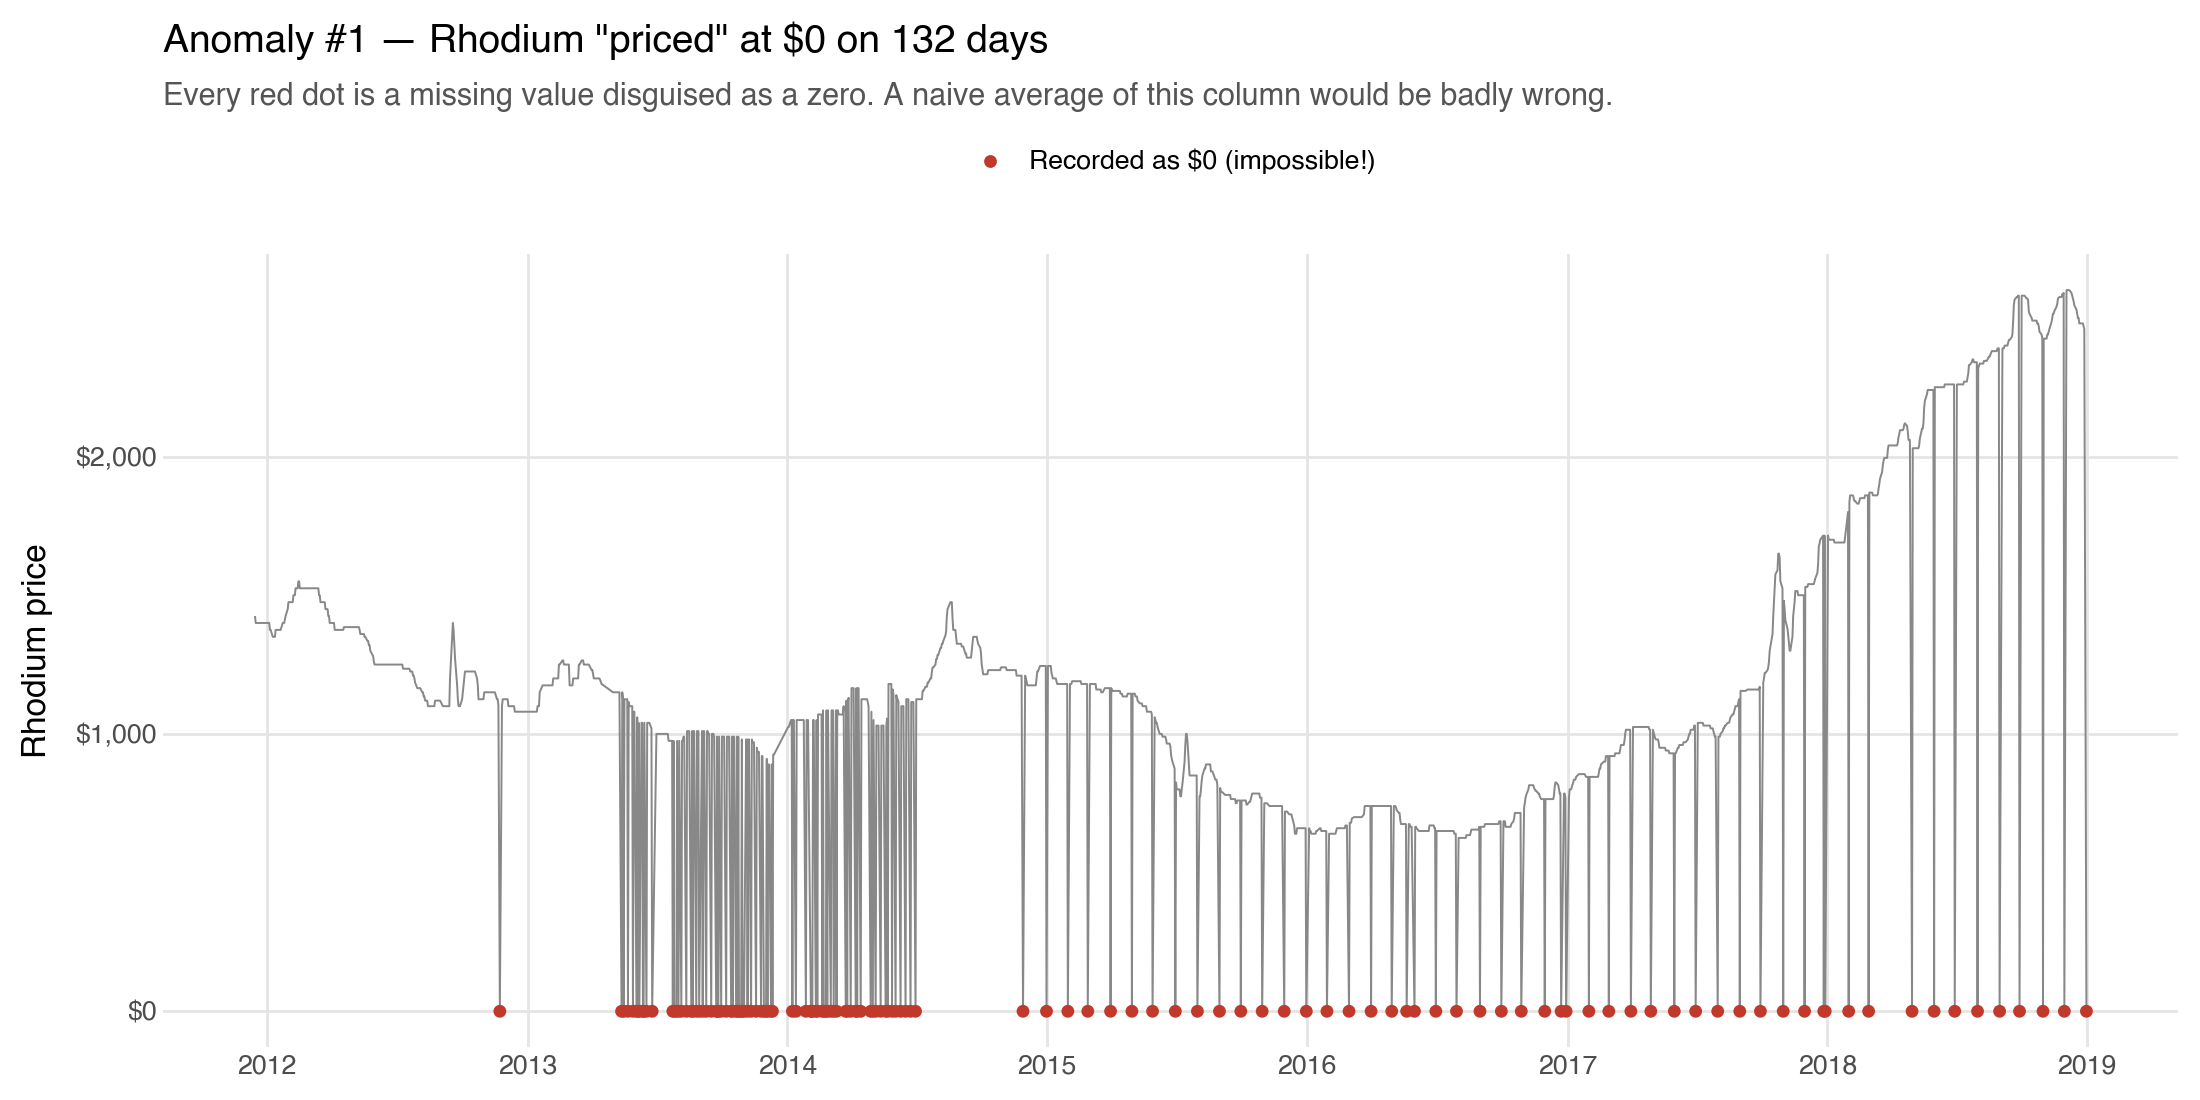

In [6]:
# Visualize the rhodium anomaly — this is what 'missing data disguised as zero' looks like
rho = pd.DataFrame({'Date': gold_d, 'Rhodium': gold_raw['RHO_PRICE']})
rho['flag'] = np.where(rho['Rhodium'] == 0, 'Recorded as $0 (impossible!)', 'Normal quote')

(ggplot(rho, aes('Date', 'Rhodium')) +
 geom_line(color='#888888', size=0.4) +
 geom_point(aes(color='flag'), data=rho[rho['Rhodium'] == 0], size=1.6) +
 scale_color_manual(values=['#C0392B']) +
 scale_y_continuous(labels=dollars) +
 scale_x_datetime(date_breaks='1 year', date_labels='%Y') +
 labs(title='Anomaly #1 — Rhodium "priced" at $0 on 132 days',
      subtitle='Every red dot is a missing value disguised as a zero. A naive average of this column would be badly wrong.',
      x='', y='Rhodium price') +
 gg_theme())

In [7]:
print('TEST 4 — Do all dates fall on trading days (Mon–Fri)?')
wk = oil_raw[oil_d.dt.dayofweek >= 5].copy()
wk['Weekday'] = oil_d[oil_d.dt.dayofweek >= 5].dt.day_name().values
print(f'   Gold file : 0 weekend rows ')
print(f'   Oil file  : {len(wk)} rows dated on a SUNDAY ')
print(wk[['Date','Weekday','Price']].head(6).to_string(index=False))
print('\n   The pattern: every one of these Sundays sits right before a US Monday holiday')
print('   (MLK Day, Presidents Day, Memorial Day, Labor Day…). Oil futures trade electronically')
print('   on Sunday evenings, and when Monday is a holiday the data vendor logged the Sunday')
print('   session as its own day. Not an error — but a quirk to know about when matching')
print('   oil days to stock-market days (stocks never trade Sundays).')

TEST 4 — Do all dates fall on trading days (Mon–Fri)?
   Gold file : 0 weekend rows 
   Oil file  : 17 rows dated on a SUNDAY 
      Date Weekday  Price
2015-01-18  Sunday  48.85
2015-02-15  Sunday  54.06
2015-05-24  Sunday  59.92
2015-09-06  Sunday  45.72
2016-01-17  Sunday  29.75
2016-02-14  Sunday  29.08

   The pattern: every one of these Sundays sits right before a US Monday holiday
   (MLK Day, Presidents Day, Memorial Day, Labor Day…). Oil futures trade electronically
   on Sunday evenings, and when Monday is a holiday the data vendor logged the Sunday
   session as its own day. Not an error — but a quirk to know about when matching
   oil days to stock-market days (stocks never trade Sundays).


In [8]:
print('TEST 5 — Holes in the calendar (gaps > 5 days between consecutive rows)')
for name, dates in [('Oil', oil_d.sort_values()), ('Gold', gold_d.sort_values())]:
    dd = dates.diff().dt.days
    gaps = dd[dd > 5]
    print(f'   {name} file: {len(gaps)} gap(s)')
    sd = dates.reset_index(drop=True); dd2 = sd.diff().dt.days
    for i in dd2[dd2 > 5].index:
        print(f'      {sd[i-1].date()} → {sd[i].date()}   ({int(dd2[i])} days missing)')
print()
print('   The April 2013 gap is the big one. GLD fell 8.8% on 15 Apr 2013 — gold\'s worst')
print('   single day in 30 years — and the file then goes SILENT for two weeks, missing the')
print('   entire aftermath and rebound. Any 2013 statistic from this file slightly')
print('   understates that crash episode. The Dec 2013 gap is a holiday-season hole.')

TEST 5 — Holes in the calendar (gaps > 5 days between consecutive rows)
   Oil file: 0 gap(s)
   Gold file: 3 gap(s)
      2013-04-15 → 2013-05-01   (16 days missing)
      2013-06-25 → 2013-07-01   (6 days missing)
      2013-12-13 → 2014-01-02   (20 days missing)

   The April 2013 gap is the big one. GLD fell 8.8% on 15 Apr 2013 — gold's worst
   single day in 30 years — and the file then goes SILENT for two weeks, missing the
   entire aftermath and rebound. Any 2013 statistic from this file slightly
   understates that crash episode. The Dec 2013 gap is a holiday-season hole.


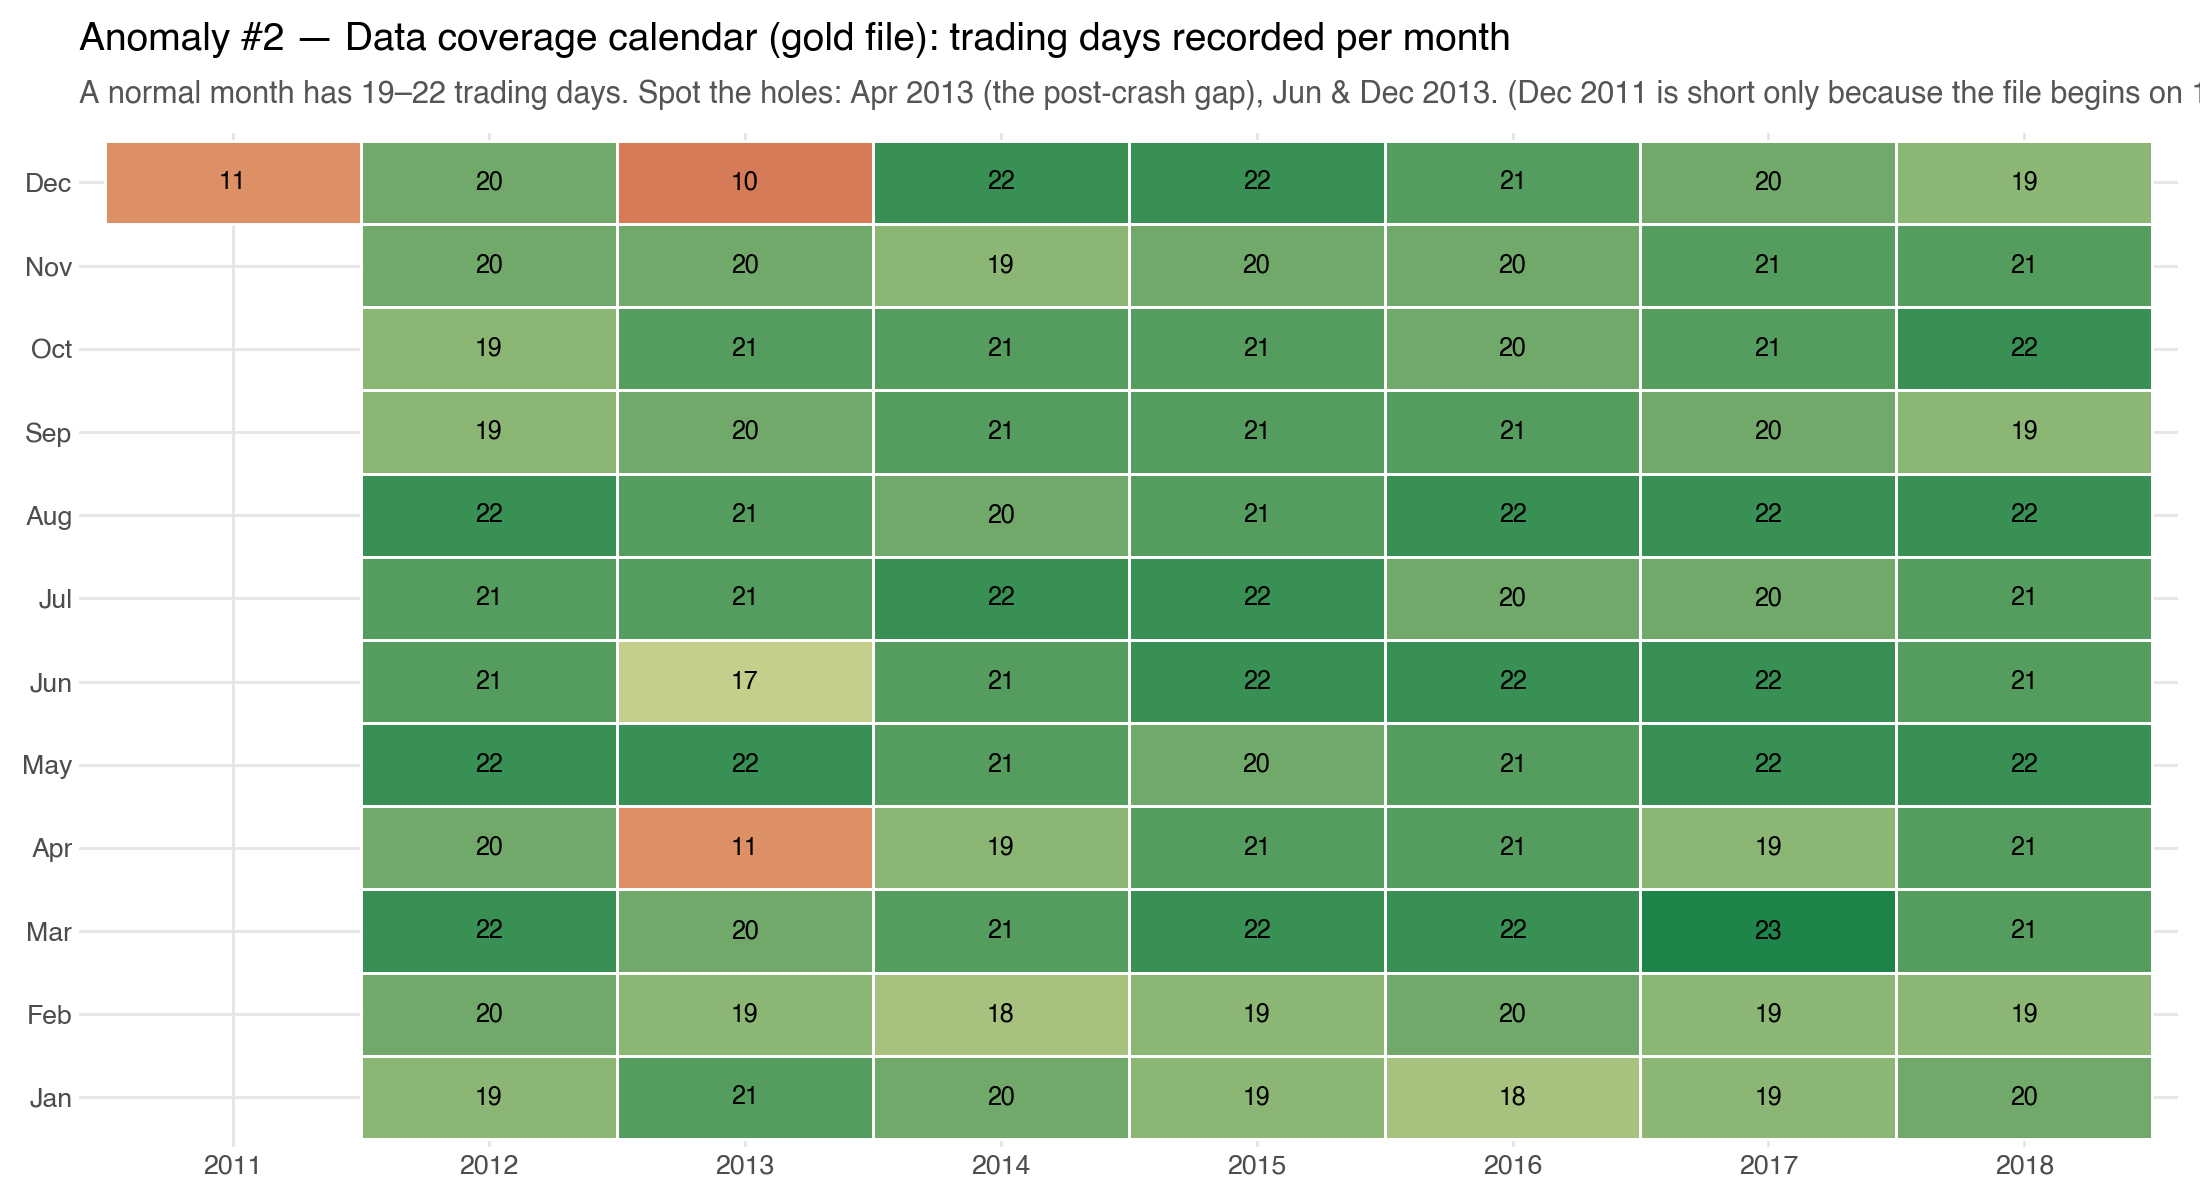

In [9]:
# Visualize data coverage: trading days recorded per month (gold file)
cov = pd.DataFrame({'Year': gold_d.dt.year, 'Month': gold_d.dt.month}).value_counts().reset_index(name='Days')
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
cov['MonthName'] = pd.Categorical([months[m-1] for m in cov['Month']], categories=months)

(ggplot(cov, aes('factor(Year)', 'MonthName', fill='Days')) +
 geom_tile(color='white', size=0.6) +
 geom_text(aes(label='Days'), size=9) +
 scale_fill_gradient2(low='#C0392B', mid='#F9E79F', high='#1E8449', midpoint=15) +
 labs(title='Anomaly #2 — Data coverage calendar (gold file): trading days recorded per month',
      subtitle='A normal month has 19–22 trading days. Spot the holes: Apr 2013 (the post-crash gap), Jun & Dec 2013. (Dec 2011 is short only because the file begins on 15 Dec.)',
      x='', y='') +
 gg_theme(11, 6) + theme(legend_position='none'))

In [10]:
print('TEST 6 — Units & cross-source sanity checks')
print(f'  Silver (SF_Price) ranges {gold_raw.SF_Price.min():,.0f} – {gold_raw.SF_Price.max():,.0f}.')
print('   Silver has NEVER cost $33,000–65,000 per ounce! These are Indian MCX futures')
print('   quoted in RUPEES per kilogram. Daily % moves are still valid for correlation,')
print('   but never read this column as a dollar price.')
print()
m_chk = pd.DataFrame({'Date': gold_d, 'USO': gold_raw['USO_Close']}).merge(
        pd.DataFrame({'Date': oil_d, 'Oil': oil_raw['Price']}), on='Date')
r_chk = m_chk.set_index('Date').pct_change().dropna()
agree = r_chk['USO'].corr(r_chk['Oil'])
opp = ((r_chk['USO'] > .01) & (r_chk['Oil'] < -.01)) | ((r_chk['USO'] < -.01) & (r_chk['Oil'] > .01))
print(f' Cross-check between the two FILES: oil price vs the oil ETF (USO) agree with')
print(f' correlation {agree:.2f}; on only {opp.sum()} of {len(r_chk):,} days did they move >1% in')
print('  opposite directions (different closing times). The two files describe the same world. ')
print()
tcols = [c for c in gold_raw.columns if 'Trend' in c]
eu_ok = ((gold_raw['EU_Price'].diff() > 0).astype(int)[1:] == gold_raw['EU_Trend'][1:]).mean()
of_ok = ((gold_raw['OF_Price'].diff() > 0).astype(int)[1:] == gold_raw['OF_Trend'][1:]).mean()
print(f'   The 9 pre-computed Trend columns (0=down, 1=up): spot-check shows EU_Trend matches the')
print(f'   actual euro direction on {eu_ok*100:.0f}% of days, OF_Trend on {of_ok*100:.0f}%. Close but NOT perfect —')
print('   another reason to compute things ourselves rather than trust derived columns.')

TEST 6 — Units & cross-source sanity checks
  Silver (SF_Price) ranges 33,170 – 65,292.
   Silver has NEVER cost $33,000–65,000 per ounce! These are Indian MCX futures
   quoted in RUPEES per kilogram. Daily % moves are still valid for correlation,
   but never read this column as a dollar price.

 Cross-check between the two FILES: oil price vs the oil ETF (USO) agree with
 correlation 0.95; on only 2 of 1,717 days did they move >1% in
  opposite directions (different closing times). The two files describe the same world. 

   The 9 pre-computed Trend columns (0=down, 1=up): spot-check shows EU_Trend matches the
   actual euro direction on 98% of days, OF_Trend on 99%. Close but NOT perfect —
   another reason to compute things ourselves rather than trust derived columns.


---
## Cleaning & repairs



In [11]:
# --- Oil ---
oil = oil_raw.copy()
oil['Date'] = pd.to_datetime(oil['Date'], format='%Y-%m-%d')

def parse_volume(v):
    v = str(v).strip()
    if v in ('-', '', 'nan'): return np.nan          # '-' means not recorded
    if v.endswith('K'): return float(v[:-1]) * 1_000
    if v.endswith('M'): return float(v[:-1]) * 1_000_000
    return float(v)

oil['Volume'] = oil['Vol.'].apply(parse_volume)
oil = oil.drop(columns=['Vol.']).sort_values('Date').reset_index(drop=True)
oil['Year'], oil['Month'] = oil['Date'].dt.year, oil['Date'].dt.month

# --- Gold & friends ---
gold = gold_raw.copy()
gold['Date'] = pd.to_datetime(gold['Date'], format='%d/%m/%Y')
gold['RHO_PRICE'] = gold['RHO_PRICE'].replace(0, np.nan)      # audit repair
gold = gold.sort_values('Date').reset_index(drop=True)
gold['Year'], gold['Month'] = gold['Date'].dt.year, gold['Date'].dt.month

print('Cleaning complete')
print(f'   Oil  : {oil.Date.min().date()} → {oil.Date.max().date()}  ({len(oil):,} days, {oil.Volume.isna().sum()} unknown volumes)')
print(f'   Gold : {gold.Date.min().date()} → {gold.Date.max().date()}  ({len(gold):,} days, {gold.RHO_PRICE.isna().sum()} rhodium repairs)')
print(f'   Days in BOTH files: {len(set(oil.Date) & set(gold.Date)):,}')

Cleaning complete
   Oil  : 2011-12-01 → 2018-12-31  (1,844 days, 62 unknown volumes)
   Gold : 2011-12-15 → 2018-12-31  (1,718 days, 132 rhodium repairs)
   Days in BOTH files: 1,718


---
## Summary statistics at a glance

In [12]:
summary = pd.DataFrame({
    'Oil ($/bbl)':     oil['Price'].describe(),
    'Gold ETF ($)':     gold['Close'].describe(),
    'S&P 500 ETF ($)':  gold['SP_close'].describe(),
    'USD Index':        gold['USDI_Price'].describe(),
}).round(2)
summary.index = ['Days of data','Average','Spread (std dev)','Lowest ever',
                 '25% of days below','Typical day (median)','75% of days below','Highest ever']
summary

,Oil ($/bbl),Gold ETF ($),S&P 500 ETF ($),USD Index
Days of data,1844.00,1718.00,1718.00,1718.00
Average,70.44,127.32,204.49,89.81
Spread (std dev),23.50,17.54,43.78,7.52
Lowest ever,26.21,100.50,120.29,78.30
25% of days below,49.06,116.05,170.40,81.38
Typical day (median),65.38,121.80,205.53,92.88
75% of days below,94.60,128.47,236.89,96.10
Highest ever,110.53,173.61,293.58,103.29


---
## The oil story 

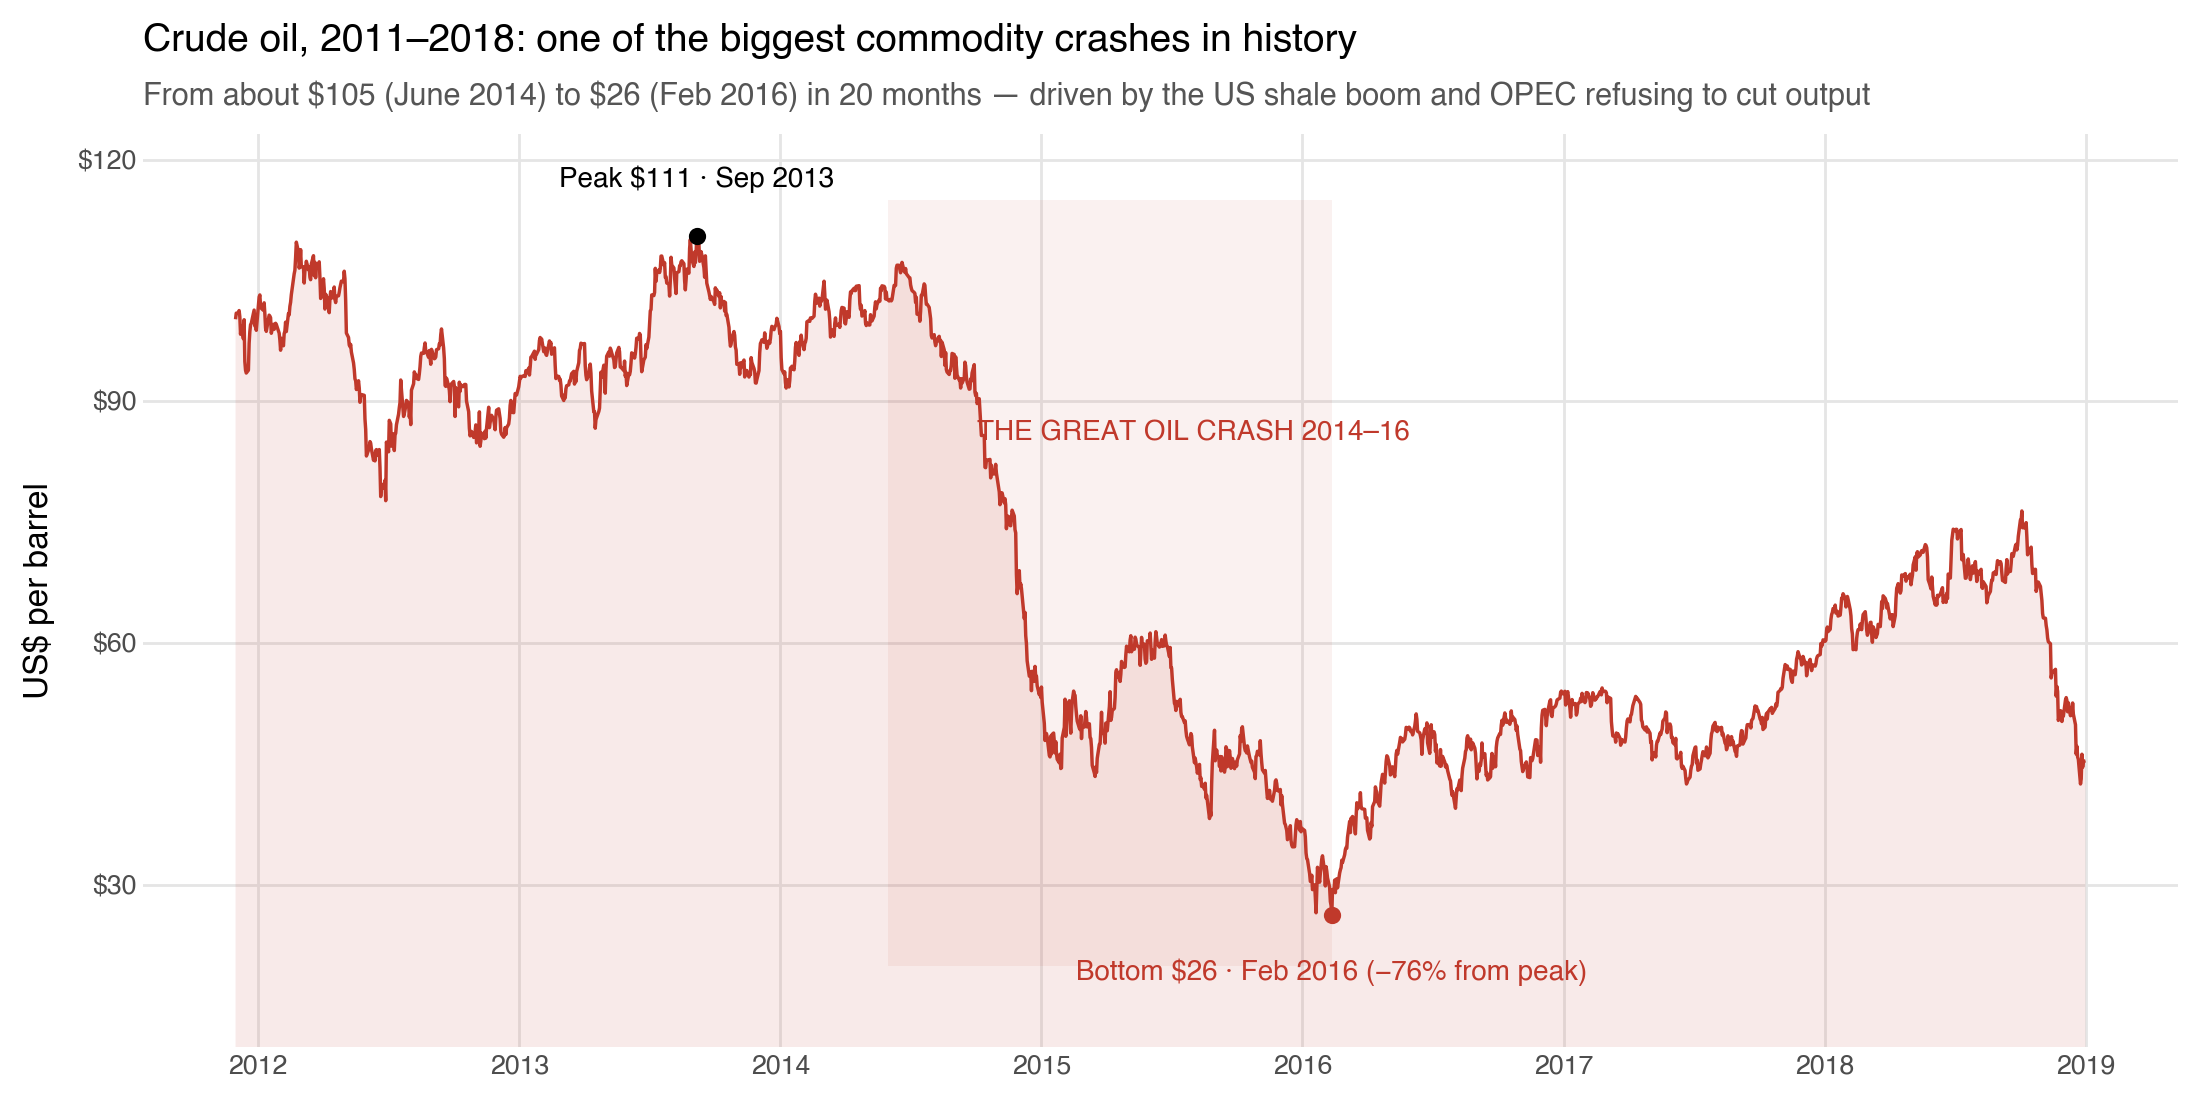

In [13]:
peak, trough = oil.loc[oil.Price.idxmax()], oil.loc[oil.Price.idxmin()]

(ggplot(oil, aes('Date', 'Price')) +
 annotate('rect', xmin=pd.Timestamp('2014-06-01'), xmax=pd.Timestamp('2016-02-11'),
          ymin=20, ymax=115, fill='#C0392B', alpha=0.07) +
 geom_area(fill='#C0392B', alpha=0.10) +
 geom_line(color='#C0392B', size=0.7) +
 annotate('point', x=peak.Date, y=peak.Price, size=2.5, color='black') +
 annotate('text', x=peak.Date, y=peak.Price + 7,
          label=f'Peak ${peak.Price:.0f} · Sep 2013', fontweight='bold', size=10) +
 annotate('point', x=trough.Date, y=trough.Price, size=2.5, color='#C0392B') +
 annotate('text', x=trough.Date, y=trough.Price - 7,
          label=f'Bottom ${trough.Price:.0f} · Feb 2016 (−76% from peak)',
          fontweight='bold', size=10, color='#C0392B') +
 annotate('text', x=pd.Timestamp('2015-08-01'), y=86,
          label='THE GREAT OIL CRASH 2014–16', fontweight='bold', size=10, color='#C0392B') +
 scale_y_continuous(labels=dollars) +
 scale_x_datetime(date_breaks='1 year', date_labels='%Y') +
 coord_cartesian(ylim=(15, 118)) +
 labs(title='Crude oil, 2011–2018: one of the biggest commodity crashes in history',
      subtitle='From about \$105 (June 2014) to \$26 (Feb 2016) in 20 months — driven by the US shale boom and OPEC refusing to cut output',
      x='', y='US$ per barrel') +
 gg_theme())

---
## The gold story

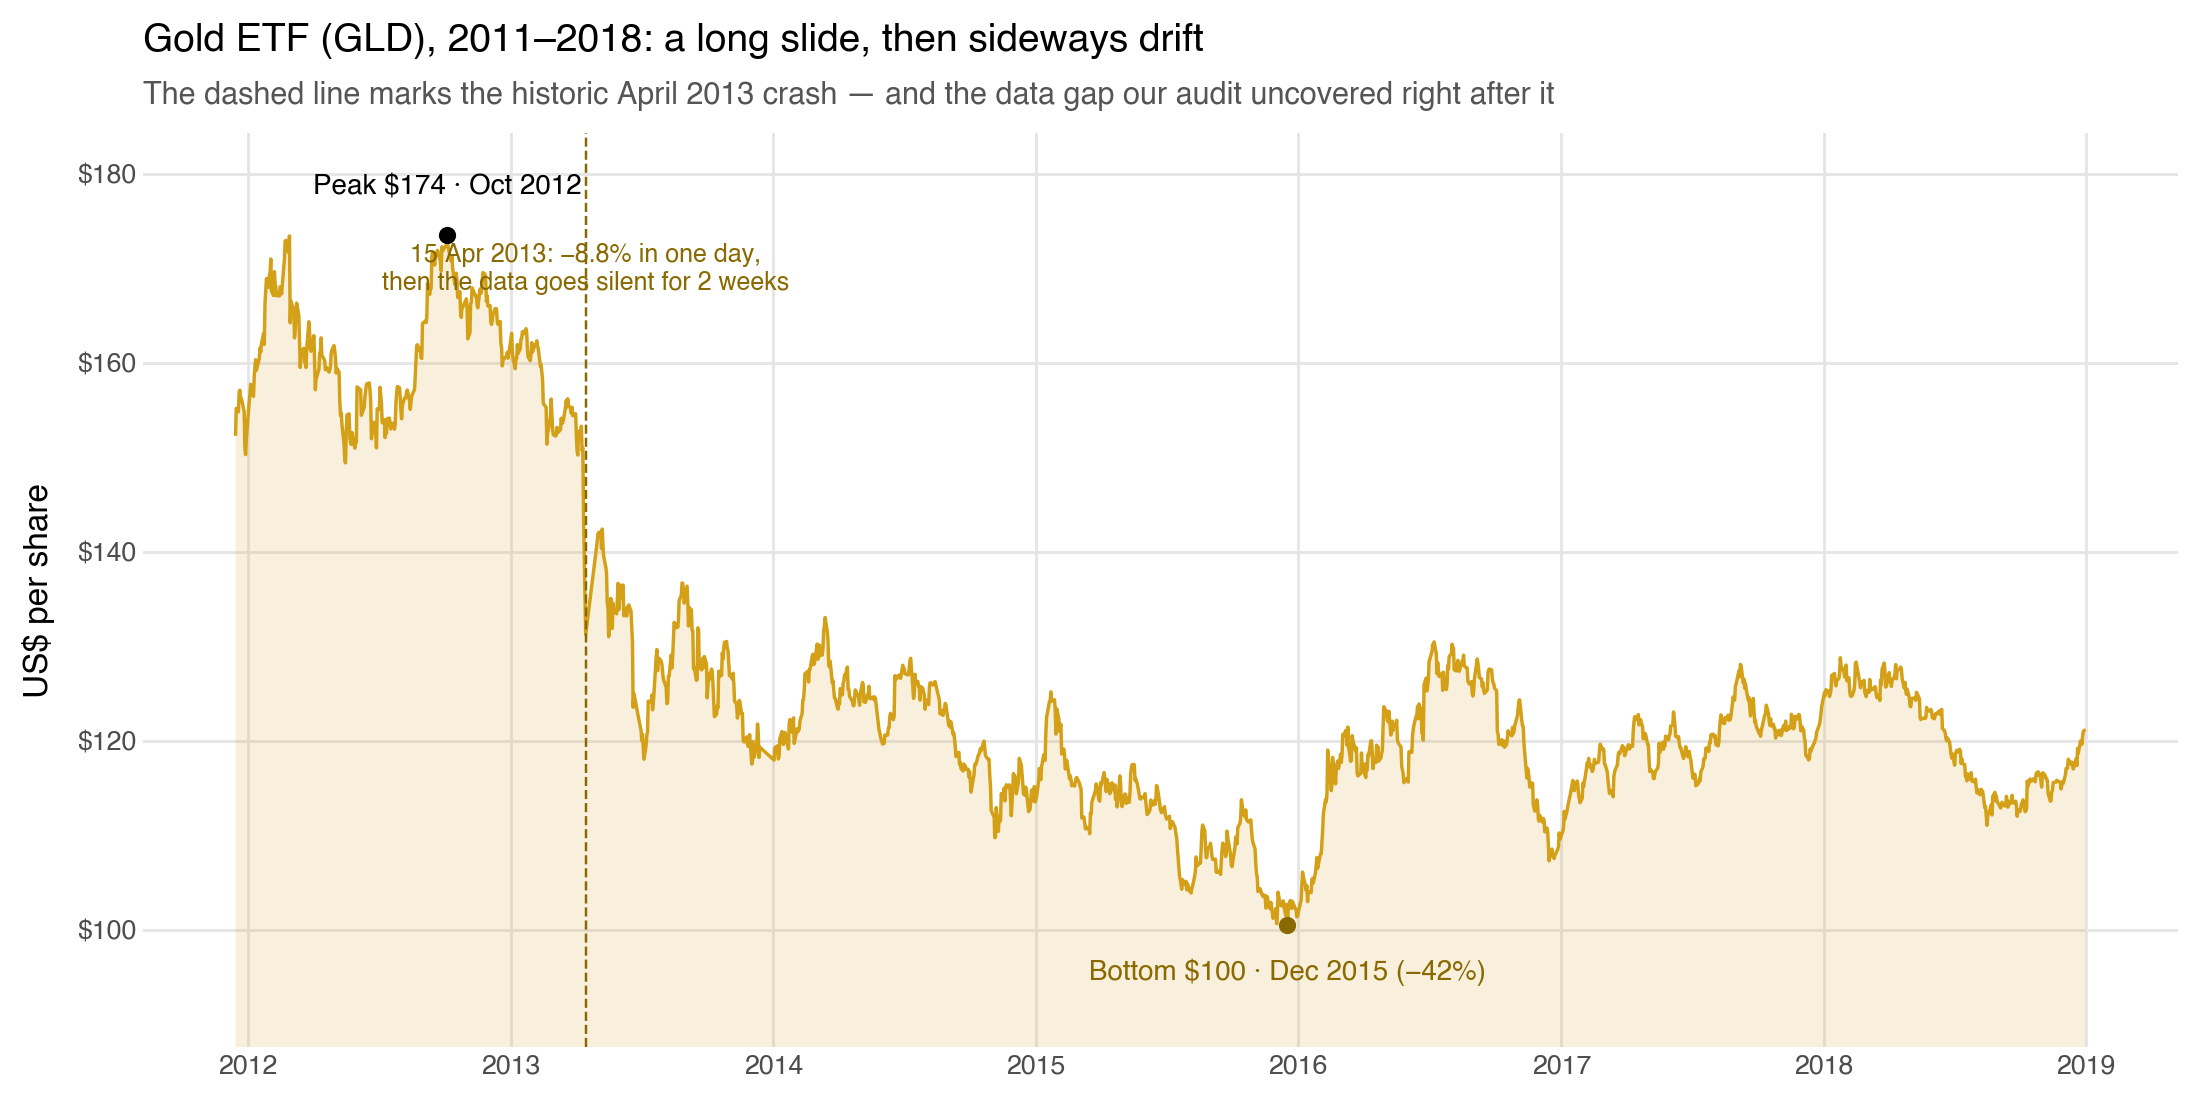

In [14]:
gpeak, gtrough = gold.loc[gold.Close.idxmax()], gold.loc[gold.Close.idxmin()]

(ggplot(gold, aes('Date', 'Close')) +
 geom_area(fill='#D4A017', alpha=0.15) +
 geom_line(color='#D4A017', size=0.7) +
 geom_vline(xintercept=pd.Timestamp('2013-04-15'), linetype='dashed', color='#8a6a00') +
 annotate('text', x=pd.Timestamp('2013-04-15'), y=170,
          label='15 Apr 2013: −8.8% in one day,\nthen the data goes silent for 2 weeks', size=9, color='#8a6a00') +
 annotate('point', x=gpeak.Date, y=gpeak.Close, size=2.5, color='black') +
 annotate('text', x=gpeak.Date, y=gpeak.Close + 5, label=f'Peak ${gpeak.Close:.0f} · Oct 2012', fontweight='bold', size=10) +
 annotate('point', x=gtrough.Date, y=gtrough.Close, size=2.5, color='#8a6a00') +
 annotate('text', x=gtrough.Date, y=gtrough.Close - 5,
          label=f'Bottom ${gtrough.Close:.0f} · Dec 2015 (−42%)', fontweight='bold', size=10, color='#8a6a00') +
 scale_y_continuous(labels=dollars) +
 scale_x_datetime(date_breaks='1 year', date_labels='%Y') +
 coord_cartesian(ylim=(92, 180)) +
 labs(title='Gold ETF (GLD), 2011–2018: a long slide, then sideways drift',
      subtitle='The dashed line marks the historic April 2013 crash — and the data gap our audit uncovered right after it',
      x='', y='US$ per share') +
 gg_theme())

---
## The big comparison: what happened to $100 invested in Dec 2011?



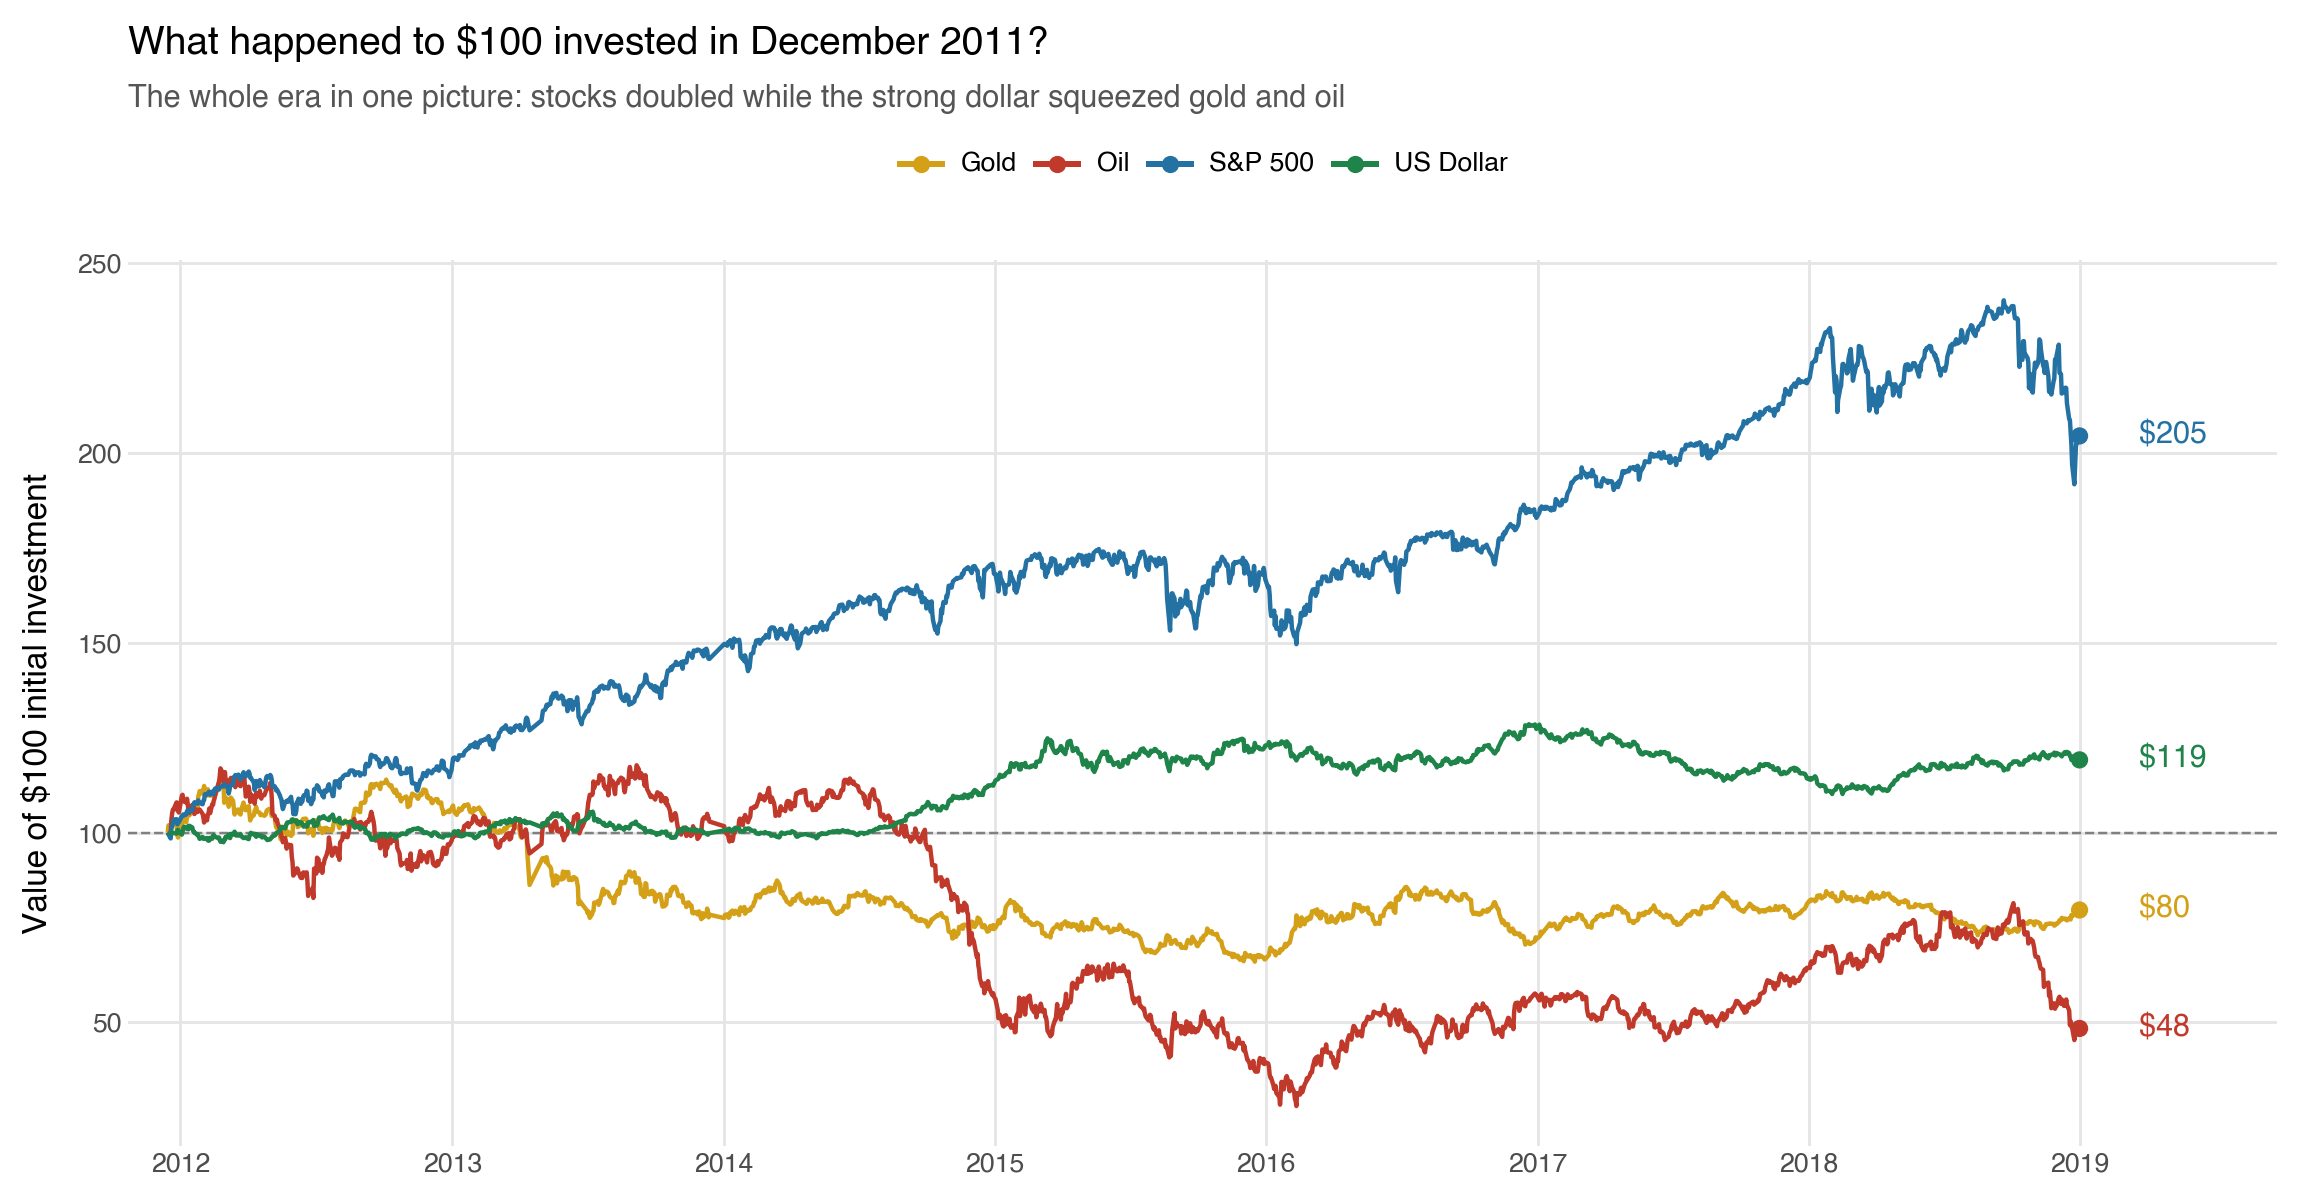

In [15]:
merged = gold.merge(oil[['Date','Price']].rename(columns={'Price':'Oil'}), on='Date', how='inner')

base = {'Gold':'Close', 'S&P 500':'SP_close', 'Oil':'Oil', 'US Dollar':'USDI_Price'}
race = pd.concat([pd.DataFrame({'Date': merged.Date, 'Asset': k,
                                'Value': merged[v]/merged[v].iloc[0]*100}) for k, v in base.items()])
last = race.groupby('Asset').tail(1).assign(lab=lambda d: '$' + d.Value.round(0).astype(int).astype(str))

(ggplot(race, aes('Date', 'Value', color='Asset')) +
 geom_hline(yintercept=100, linetype='dashed', color='gray') +
 geom_line(size=0.9) +
 geom_point(data=last, size=2.5) +
 geom_text(aes(label='lab'), data=last, nudge_x=80, fontweight='bold', size=11, ha='left', show_legend=False) +
 scale_color_manual(values=PALETTE) +
 scale_x_datetime(date_breaks='1 year', date_labels='%Y',
                  expand=(0.02, 0, 0.07, 0)) +
 labs(title='What happened to $100 invested in December 2011?',
      subtitle='The whole era in one picture: stocks doubled while the strong dollar squeezed gold and oil',
      x='', y='Value of $100 initial investment') +
 gg_theme(11.5, 6))

---
## Risk: which asset gave the wildest ride?


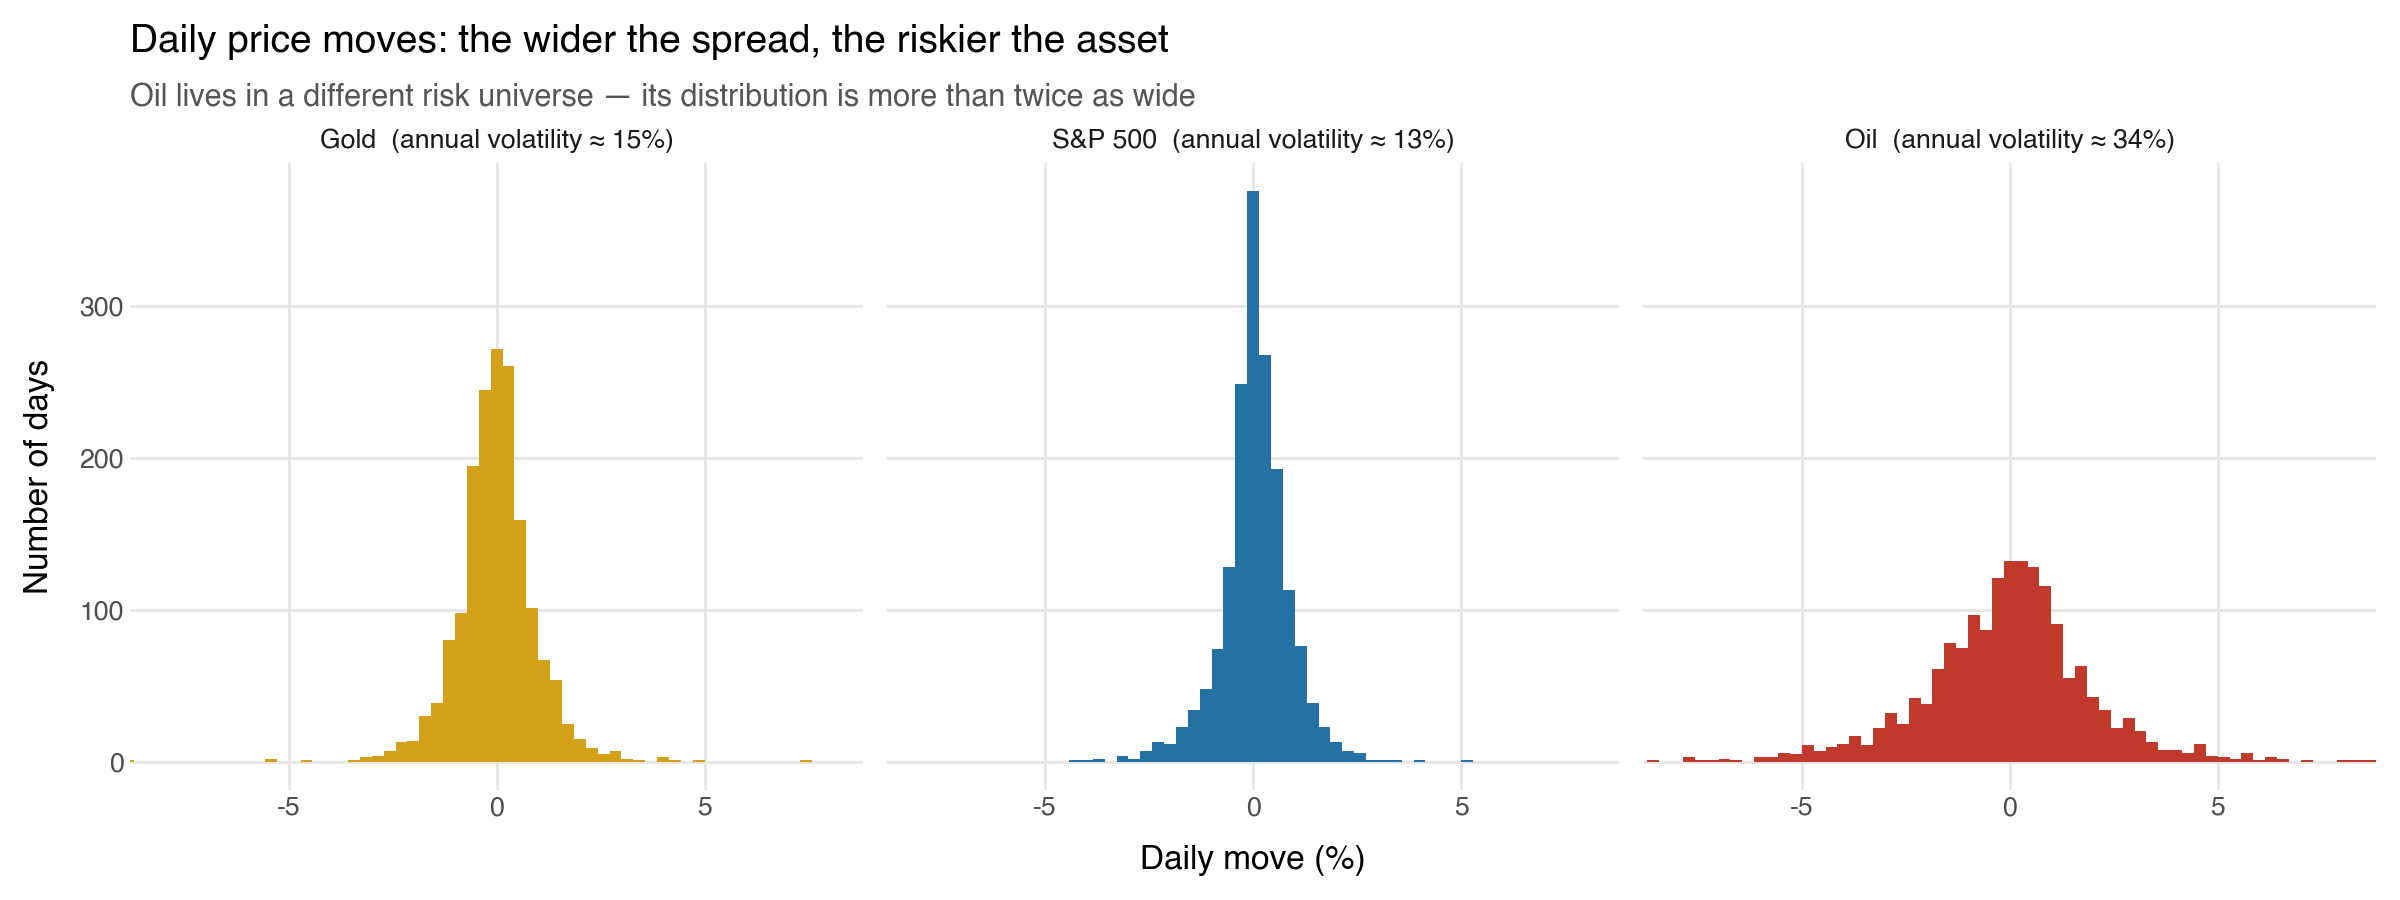

In [16]:
rets = pd.DataFrame({'Date': merged.Date,
                     'Gold': merged.Close.pct_change()*100,
                     'S&P 500': merged.SP_close.pct_change()*100,
                     'Oil': merged.Oil.pct_change()*100}).dropna()
vols = {a: f'{a}  (annual volatility ≈ {rets[a].std()*np.sqrt(252):.0f}%)' for a in ['Gold','S&P 500','Oil']}
rl = rets.melt('Date', var_name='Asset', value_name='ret')
rl['Panel'] = rl.Asset.map(vols)
rl['Panel'] = pd.Categorical(rl.Panel, categories=[vols['Gold'], vols['S&P 500'], vols['Oil']])

(ggplot(rl, aes('ret', fill='Asset')) +
 geom_histogram(bins=80, show_legend=False) +
 facet_wrap('~Panel') +
 scale_fill_manual(values=PALETTE) +
 coord_cartesian(xlim=(-8, 8)) +
 labs(title='Daily price moves: the wider the spread, the riskier the asset',
      subtitle='Oil lives in a different risk universe — its distribution is more than twice as wide',
      x='Daily move (%)', y='Number of days') +
 gg_theme(12, 4.5))

In [17]:
print('Most extreme single days:')
print(f"   Oil worst : {rets.loc[rets.Oil.idxmin(),'Date'].date()}  {rets.Oil.min():+.1f}%   ← the day OPEC refused to cut production")
print(f"   Oil best  : {rets.loc[rets.Oil.idxmax(),'Date'].date()}  {rets.Oil.max():+.1f}%   ← rebound off the $26 bottom")
print(f"   Gold worst: {rets.loc[rets.Gold.idxmin(),'Date'].date()}  {rets.Gold.min():+.1f}%   ← the historic April 2013 crash")
big = lambda a: (rets[a].abs() > 5).sum()
print(f"\n   Days moving more than ±5%:  Oil {big('Oil')}  |  Gold {big('Gold')}  |  S&P 500 {big('S&P 500')}")

Most extreme single days:
   Oil worst : 2014-11-28  -10.2%   ← the day OPEC refused to cut production
   Oil best  : 2016-02-12  +12.3%   ← rebound off the $26 bottom
   Gold worst: 2013-04-15  -8.8%   ← the historic April 2013 crash

   Days moving more than ±5%:  Oil 55  |  Gold 4  |  S&P 500 1


---
## Correlation

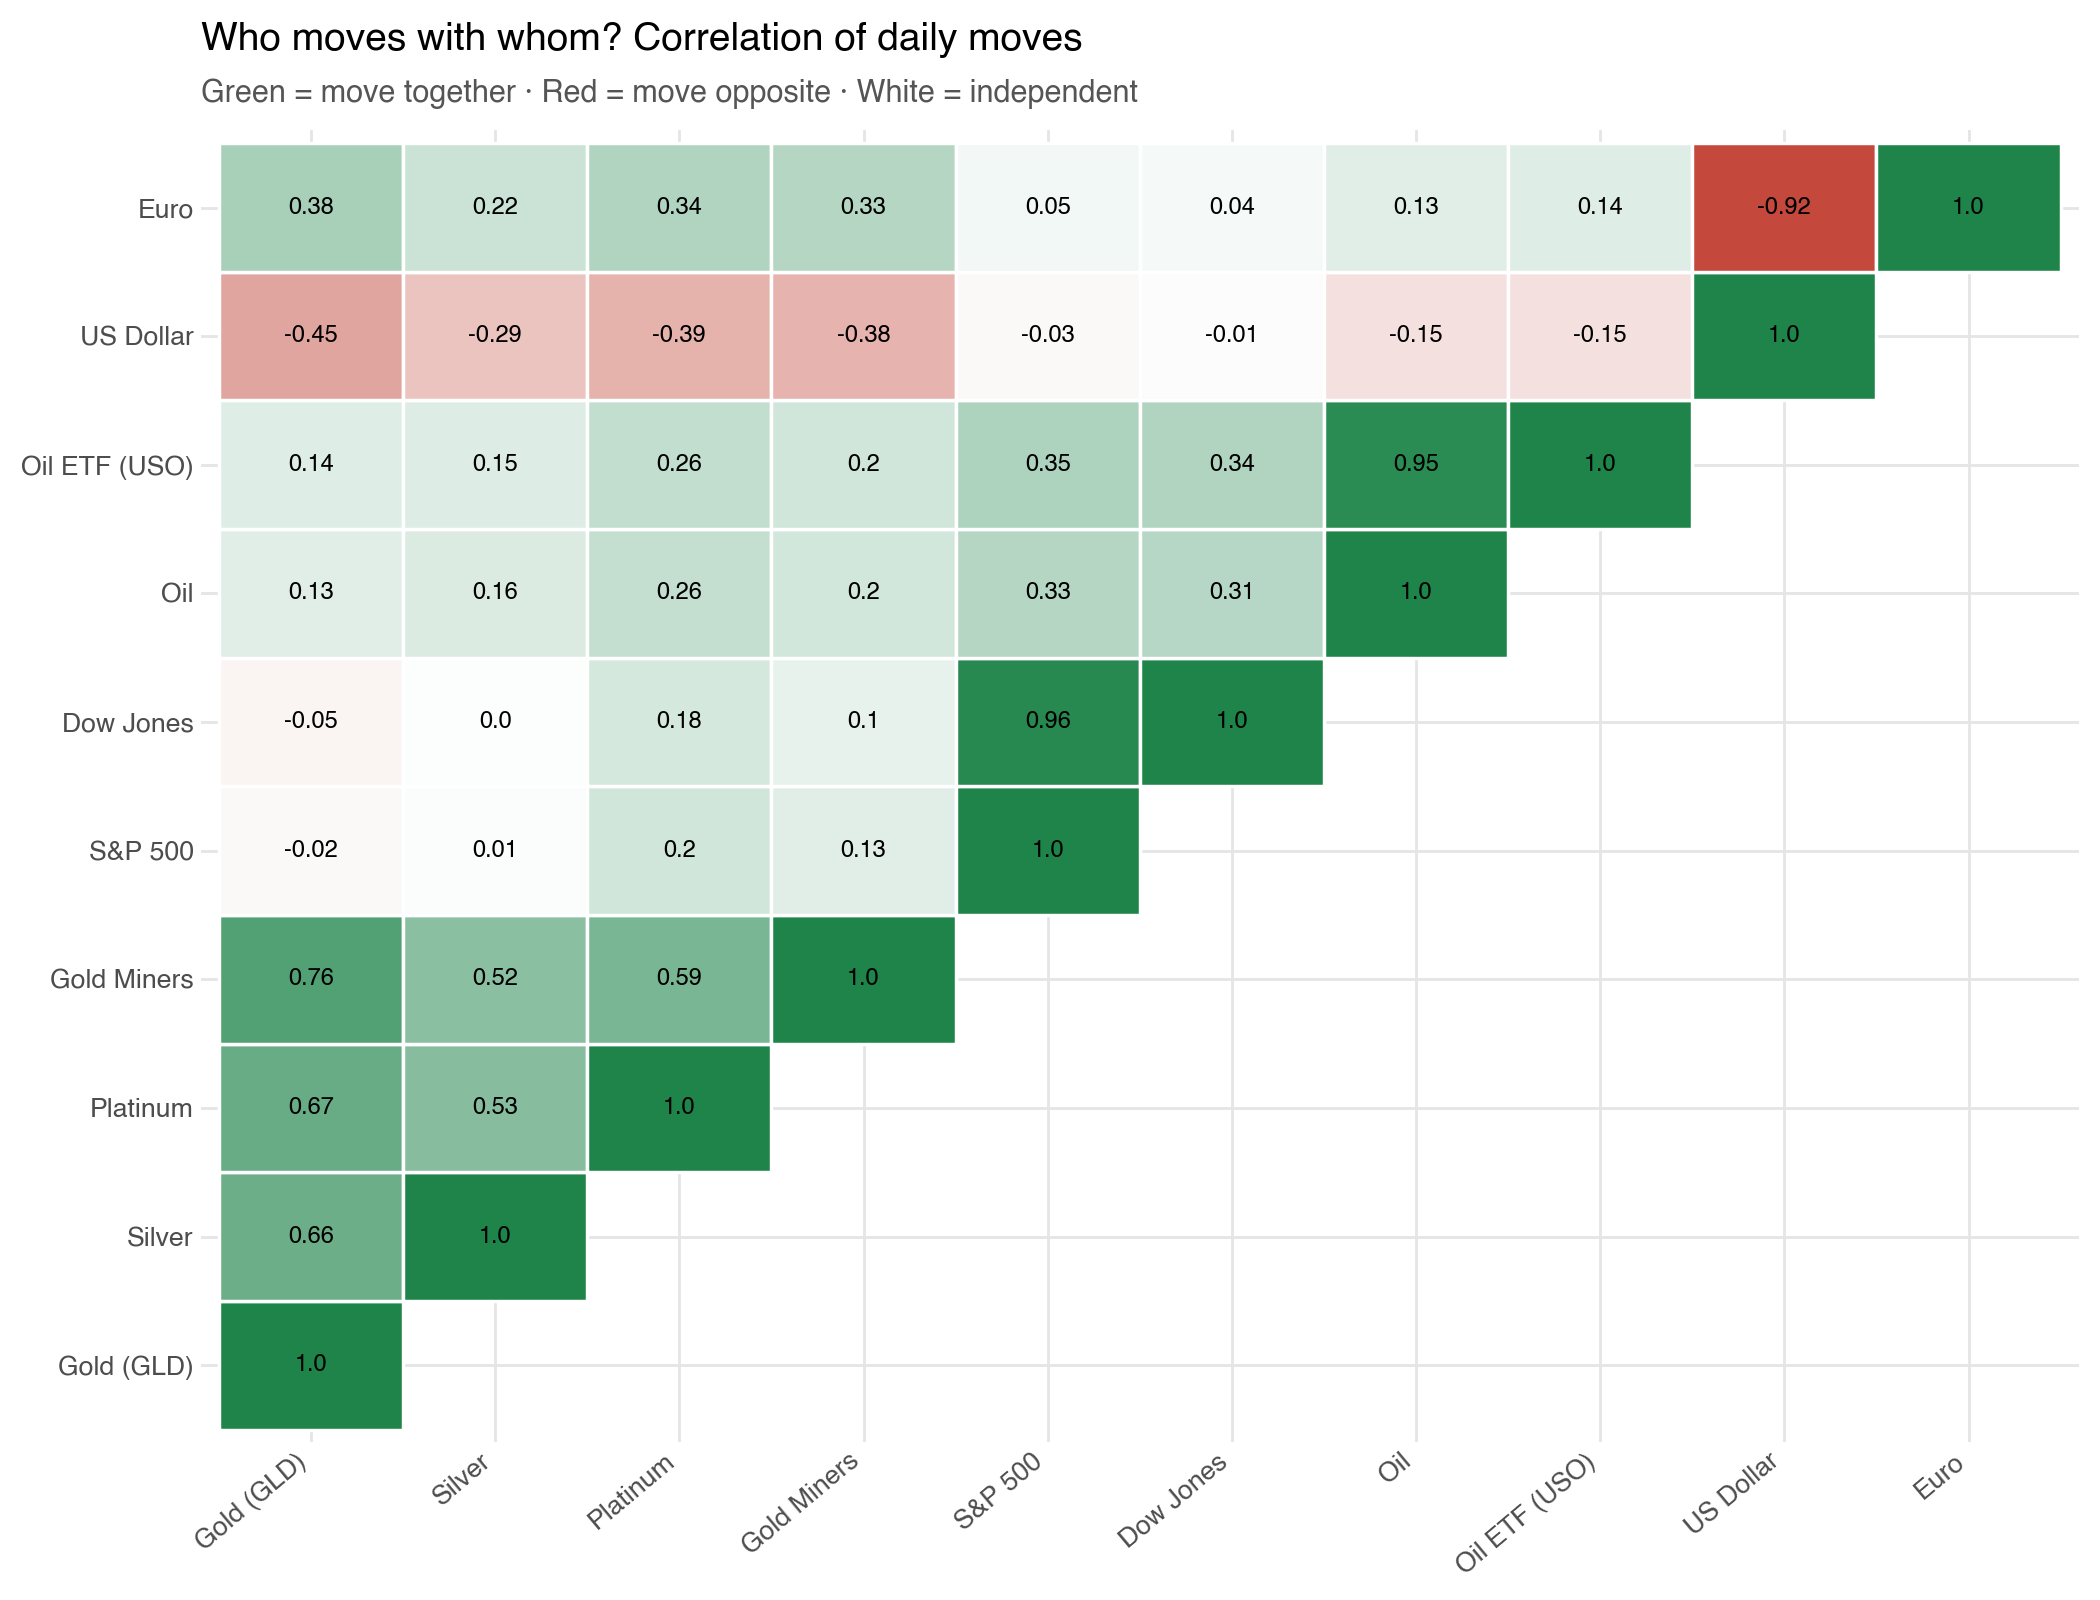

In [18]:
cmap_cols = {'Close':'Gold (GLD)', 'SF_Price':'Silver', 'PLT_Price':'Platinum',
             'GDX_Close':'Gold Miners', 'SP_close':'S&P 500', 'DJ_close':'Dow Jones',
             'Oil':'Oil', 'USO_Close':'Oil ETF (USO)', 'USDI_Price':'US Dollar', 'EU_Price':'Euro'}
corr = merged[list(cmap_cols)].pct_change().dropna().rename(columns=cmap_cols).corr()
order = list(corr.columns)
cl = corr.reset_index(names='a').melt('a', var_name='b', value_name='r')
cl['ai'] = cl.a.map({k:i for i,k in enumerate(order)}); cl['bi'] = cl.b.map({k:i for i,k in enumerate(order)})
cl = cl[cl.ai >= cl.bi]                       # lower triangle only
cl['a'] = pd.Categorical(cl.a, categories=order)
cl['b'] = pd.Categorical(cl.b, categories=order)

(ggplot(cl, aes('b', 'a', fill='r')) +
 geom_tile(color='white', size=0.7) +
 geom_text(aes(label='r.round(2)'), size=8.5) +
 scale_fill_gradient2(low='#C0392B', mid='#FDFEFE', high='#1E8449', limits=(-1, 1)) +
 labs(title='Who moves with whom? Correlation of daily moves',
      subtitle='Green = move together · Red = move opposite · White = independent',
      x='', y='', fill='') +
 gg_theme(10.5, 8) +
 theme(axis_text_x=element_text(rotation=40, ha='right'), legend_position='none'))

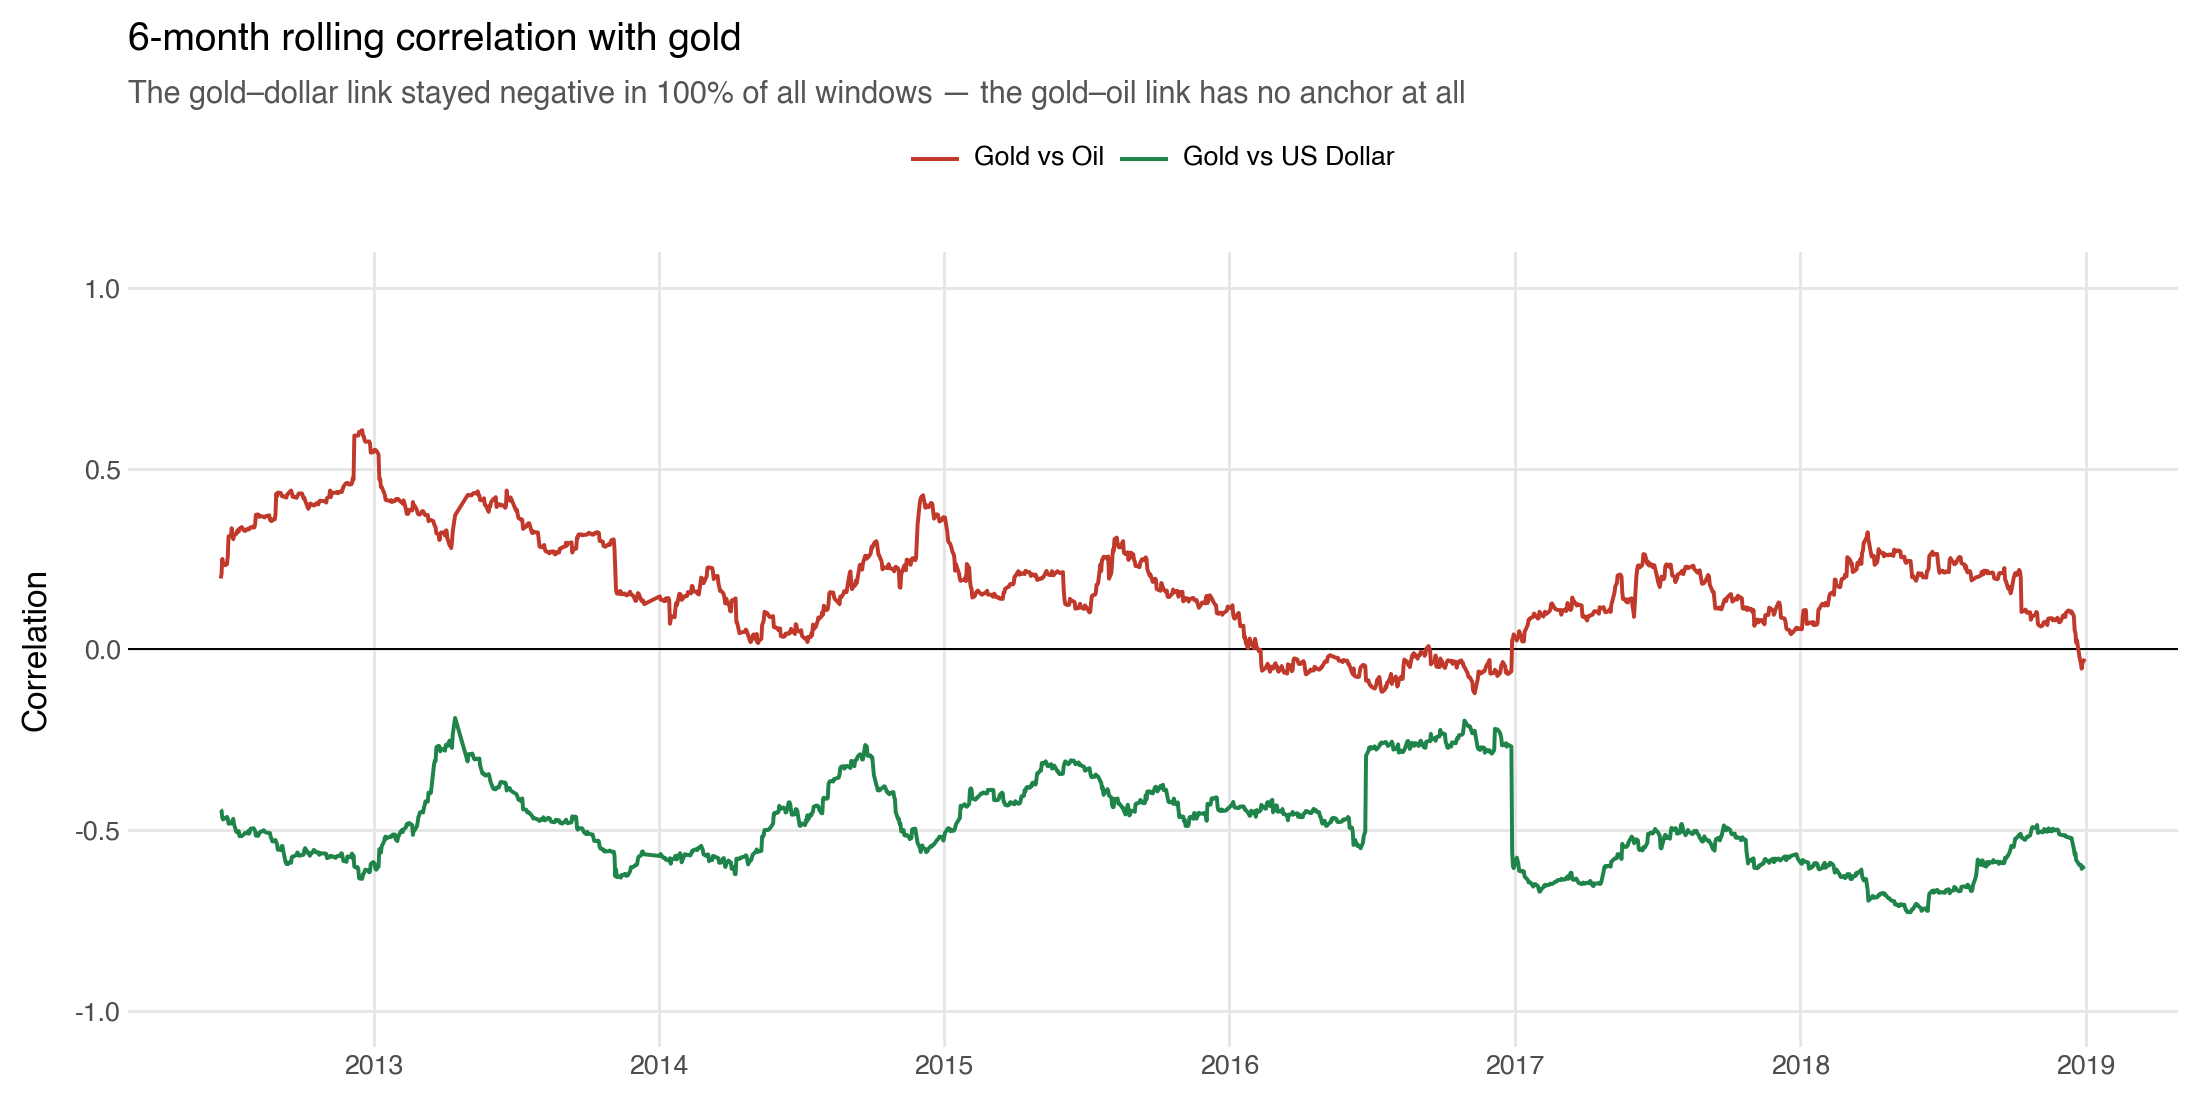

In [19]:
daily = merged.set_index('Date')[['Close','USDI_Price','Oil']].pct_change().dropna()
roll = pd.DataFrame({
    'Gold vs US Dollar': daily.Close.rolling(126).corr(daily.USDI_Price),
    'Gold vs Oil':       daily.Close.rolling(126).corr(daily.Oil)}).dropna()
rl2 = roll.reset_index().melt('Date', var_name='Pair', value_name='corr')

(ggplot(rl2, aes('Date', 'corr', color='Pair')) +
 geom_hline(yintercept=0, color='black', size=0.4) +
 geom_line(size=0.8) +
 scale_color_manual(values={'Gold vs US Dollar': '#1E8449', 'Gold vs Oil': '#C0392B'}) +
 scale_x_datetime(date_breaks='1 year', date_labels='%Y') +
 coord_cartesian(ylim=(-1, 1)) +
 labs(title='6-month rolling correlation with gold',
      subtitle=f'The gold–dollar link stayed negative in {(roll["Gold vs US Dollar"]<0).mean()*100:.0f}% of all windows — the gold–oil link has no anchor at all',
      x='', y='Correlation') +
 gg_theme())

---
## Year-by-year report card

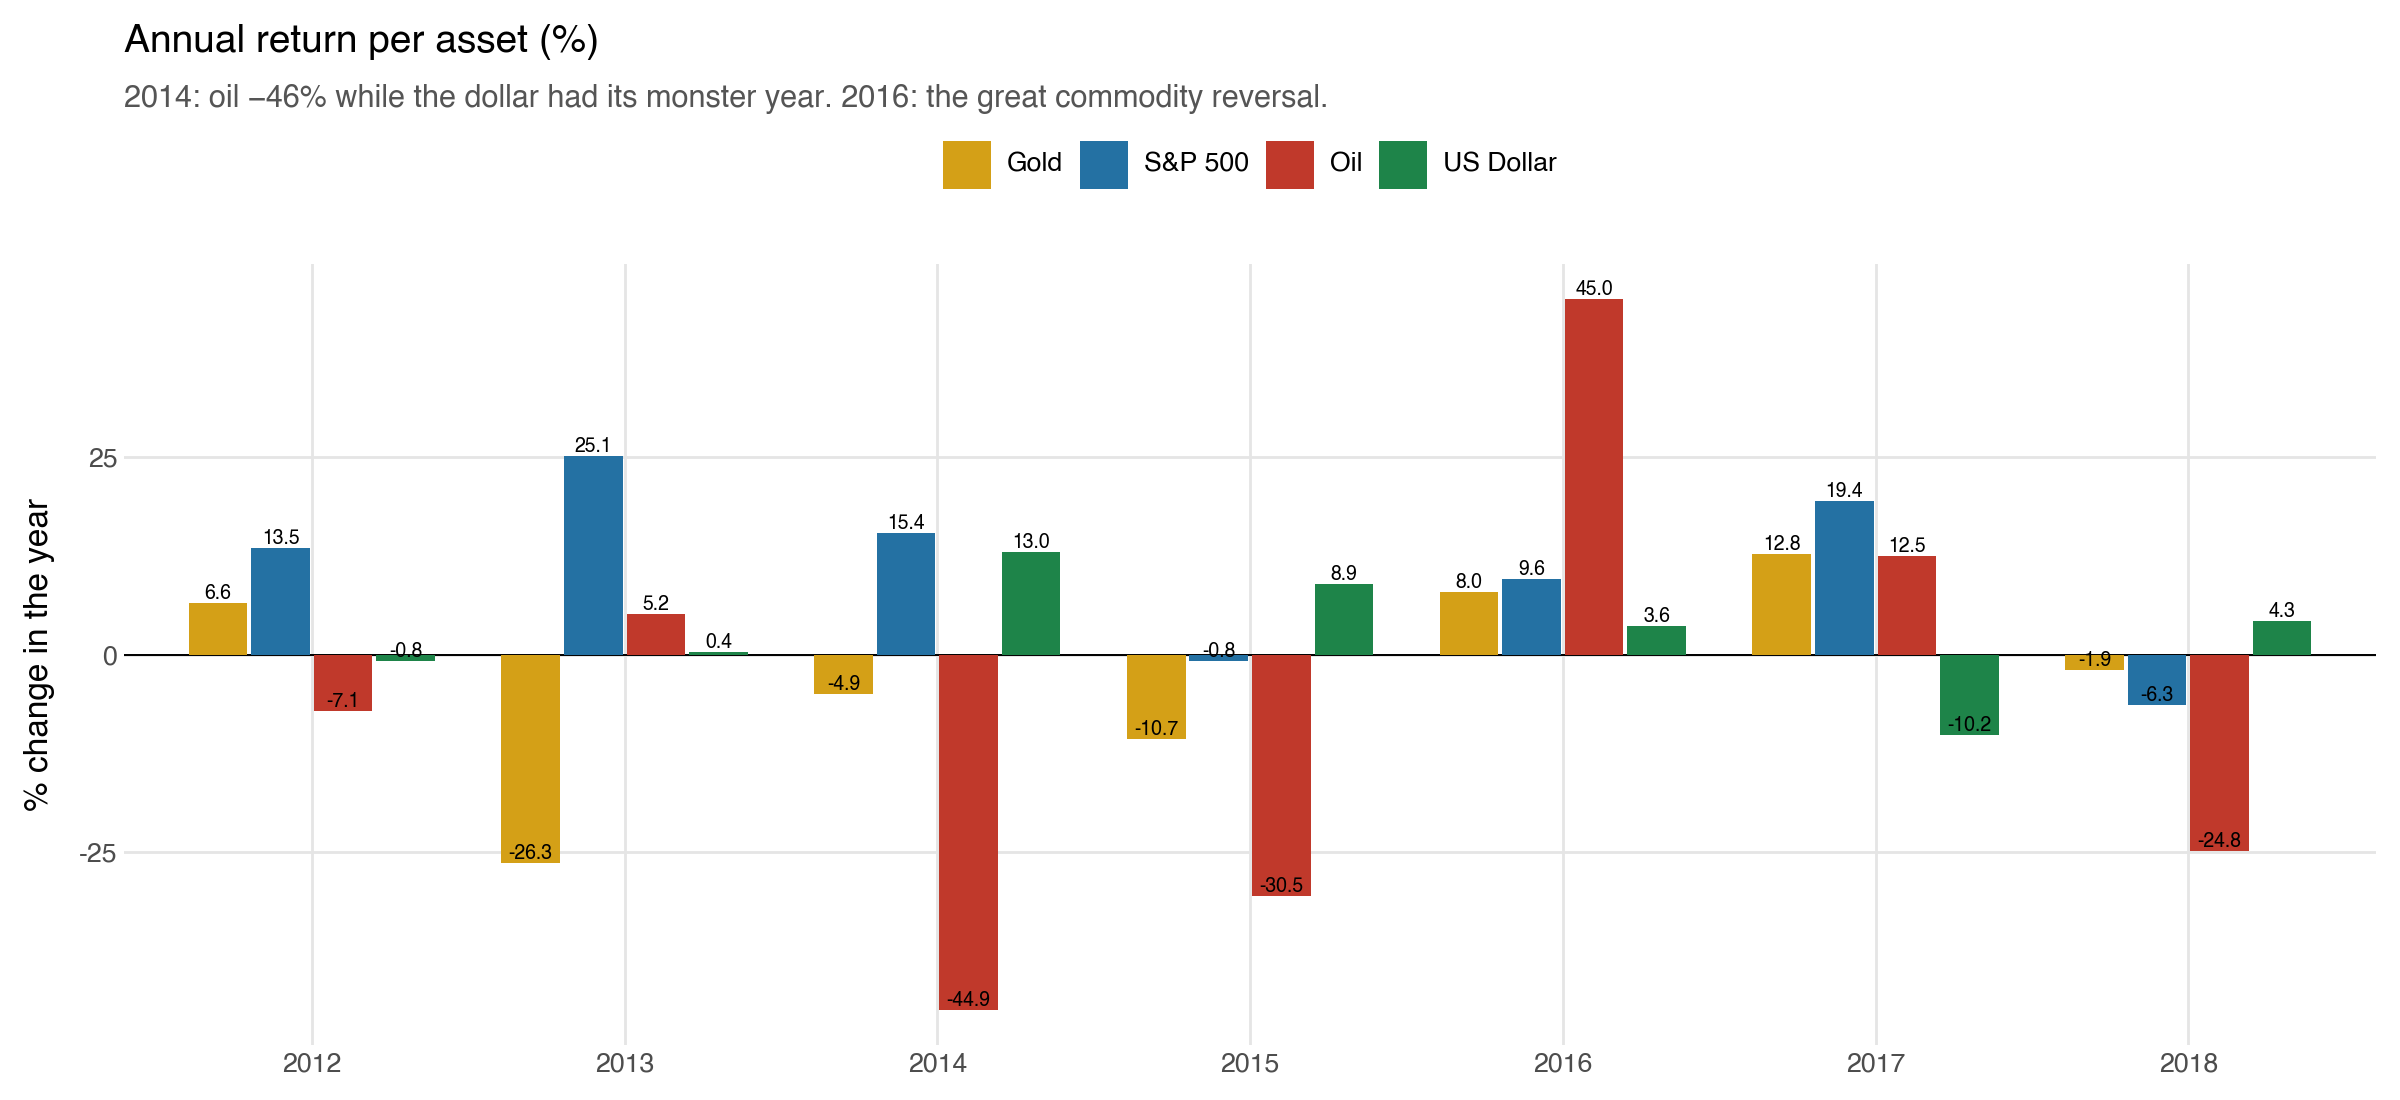

In [20]:
yearly = merged.groupby(merged.Date.dt.year).agg(
    Gold=('Close','last'), **{'S&P 500':('SP_close','last')}, Oil=('Oil','last'), **{'US Dollar':('USDI_Price','last')})
yr = (yearly.pct_change()*100).dropna().round(1)
yl = yr.reset_index(names='Year').melt('Year', var_name='Asset', value_name='Return')
yl['Asset'] = pd.Categorical(yl.Asset, categories=['Gold','S&P 500','Oil','US Dollar'])

(ggplot(yl, aes('factor(Year)', 'Return', fill='Asset')) +
 geom_hline(yintercept=0, color='black', size=0.4) +
 geom_col(position=position_dodge(0.8), width=0.75) +
 geom_text(aes(label='Return'), position=position_dodge(0.8), size=7, va='bottom') +
 scale_fill_manual(values=PALETTE) +
 labs(title='Annual return per asset (%)',
      subtitle='2014: oil −46% while the dollar had its monster year. 2016: the great commodity reversal.',
      x='', y='% change in the year') +
 gg_theme(12, 5.5))

---
## Drawdowns: the "pain chart"



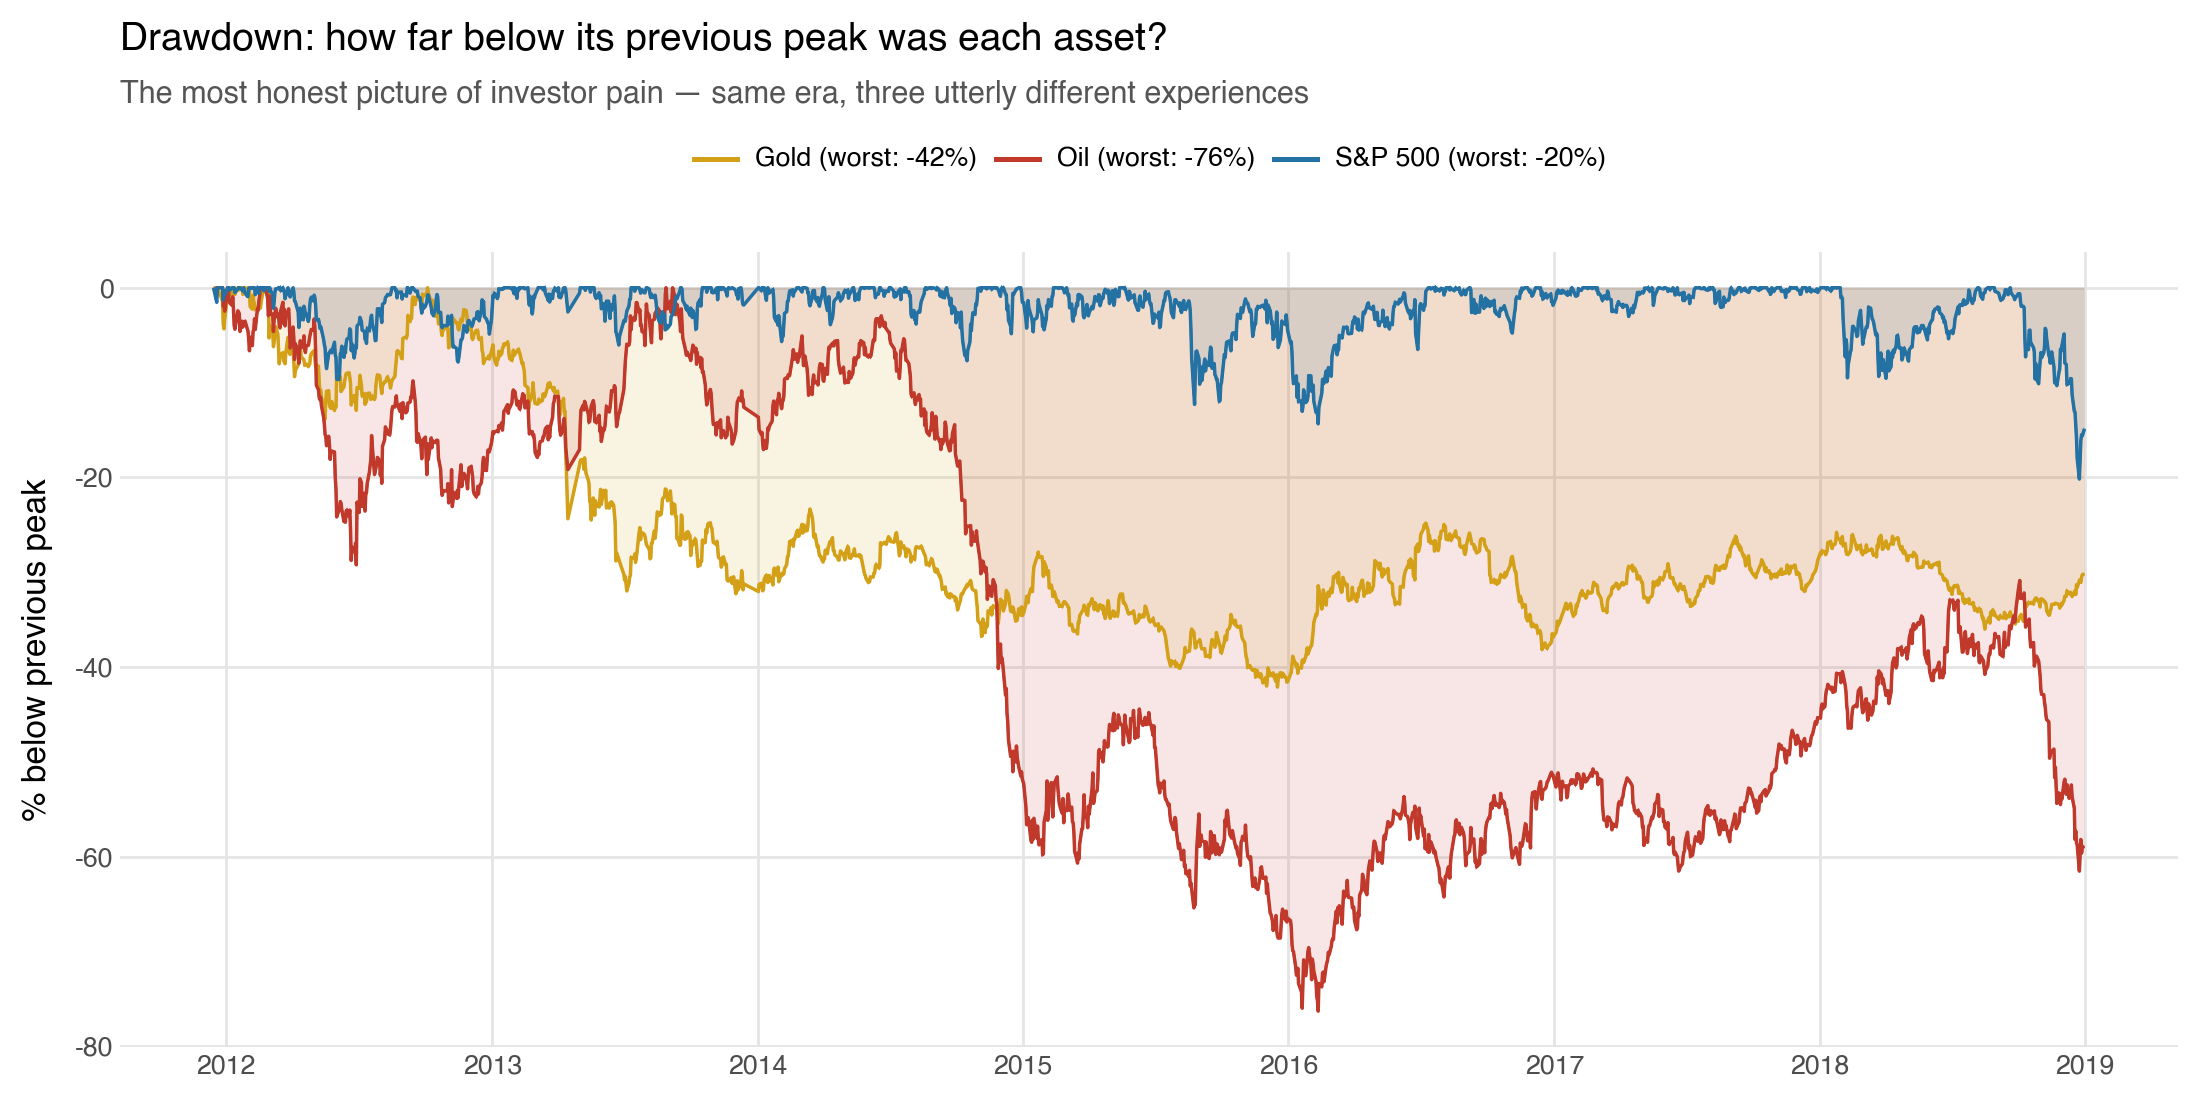

In [21]:
dd_frames = []
for col, label in [('Oil','Oil'), ('Close','Gold'), ('SP_close','S&P 500')]:
    s = merged.set_index('Date')[col]
    d = (s/s.cummax()-1)*100
    dd_frames.append(pd.DataFrame({'Date': d.index, 'DD': d.values,
                                   'Asset': f'{label} (worst: {d.min():.0f}%)',
                                   'key': label}))
ddl = pd.concat(dd_frames)
keys = {f.key.iloc[0]: f.Asset.iloc[0] for f in dd_frames}
pal2 = {keys['Oil']:'#C0392B', keys['Gold']:'#D4A017', keys['S&P 500']:'#2471A3'}

(ggplot(ddl, aes('Date', 'DD', color='Asset', fill='Asset')) +
 geom_area(alpha=0.12, position='identity', show_legend=False) +
 geom_line(size=0.7) +
 scale_color_manual(values=pal2) + scale_fill_manual(values=pal2) +
 scale_x_datetime(date_breaks='1 year', date_labels='%Y') +
 labs(title='Drawdown: how far below its previous peak was each asset?',
      subtitle='The most honest picture of investor pain — same era, three utterly different experiences',
      x='', y='% below previous peak') +
 gg_theme())

---
## Trading volume: panic is visible



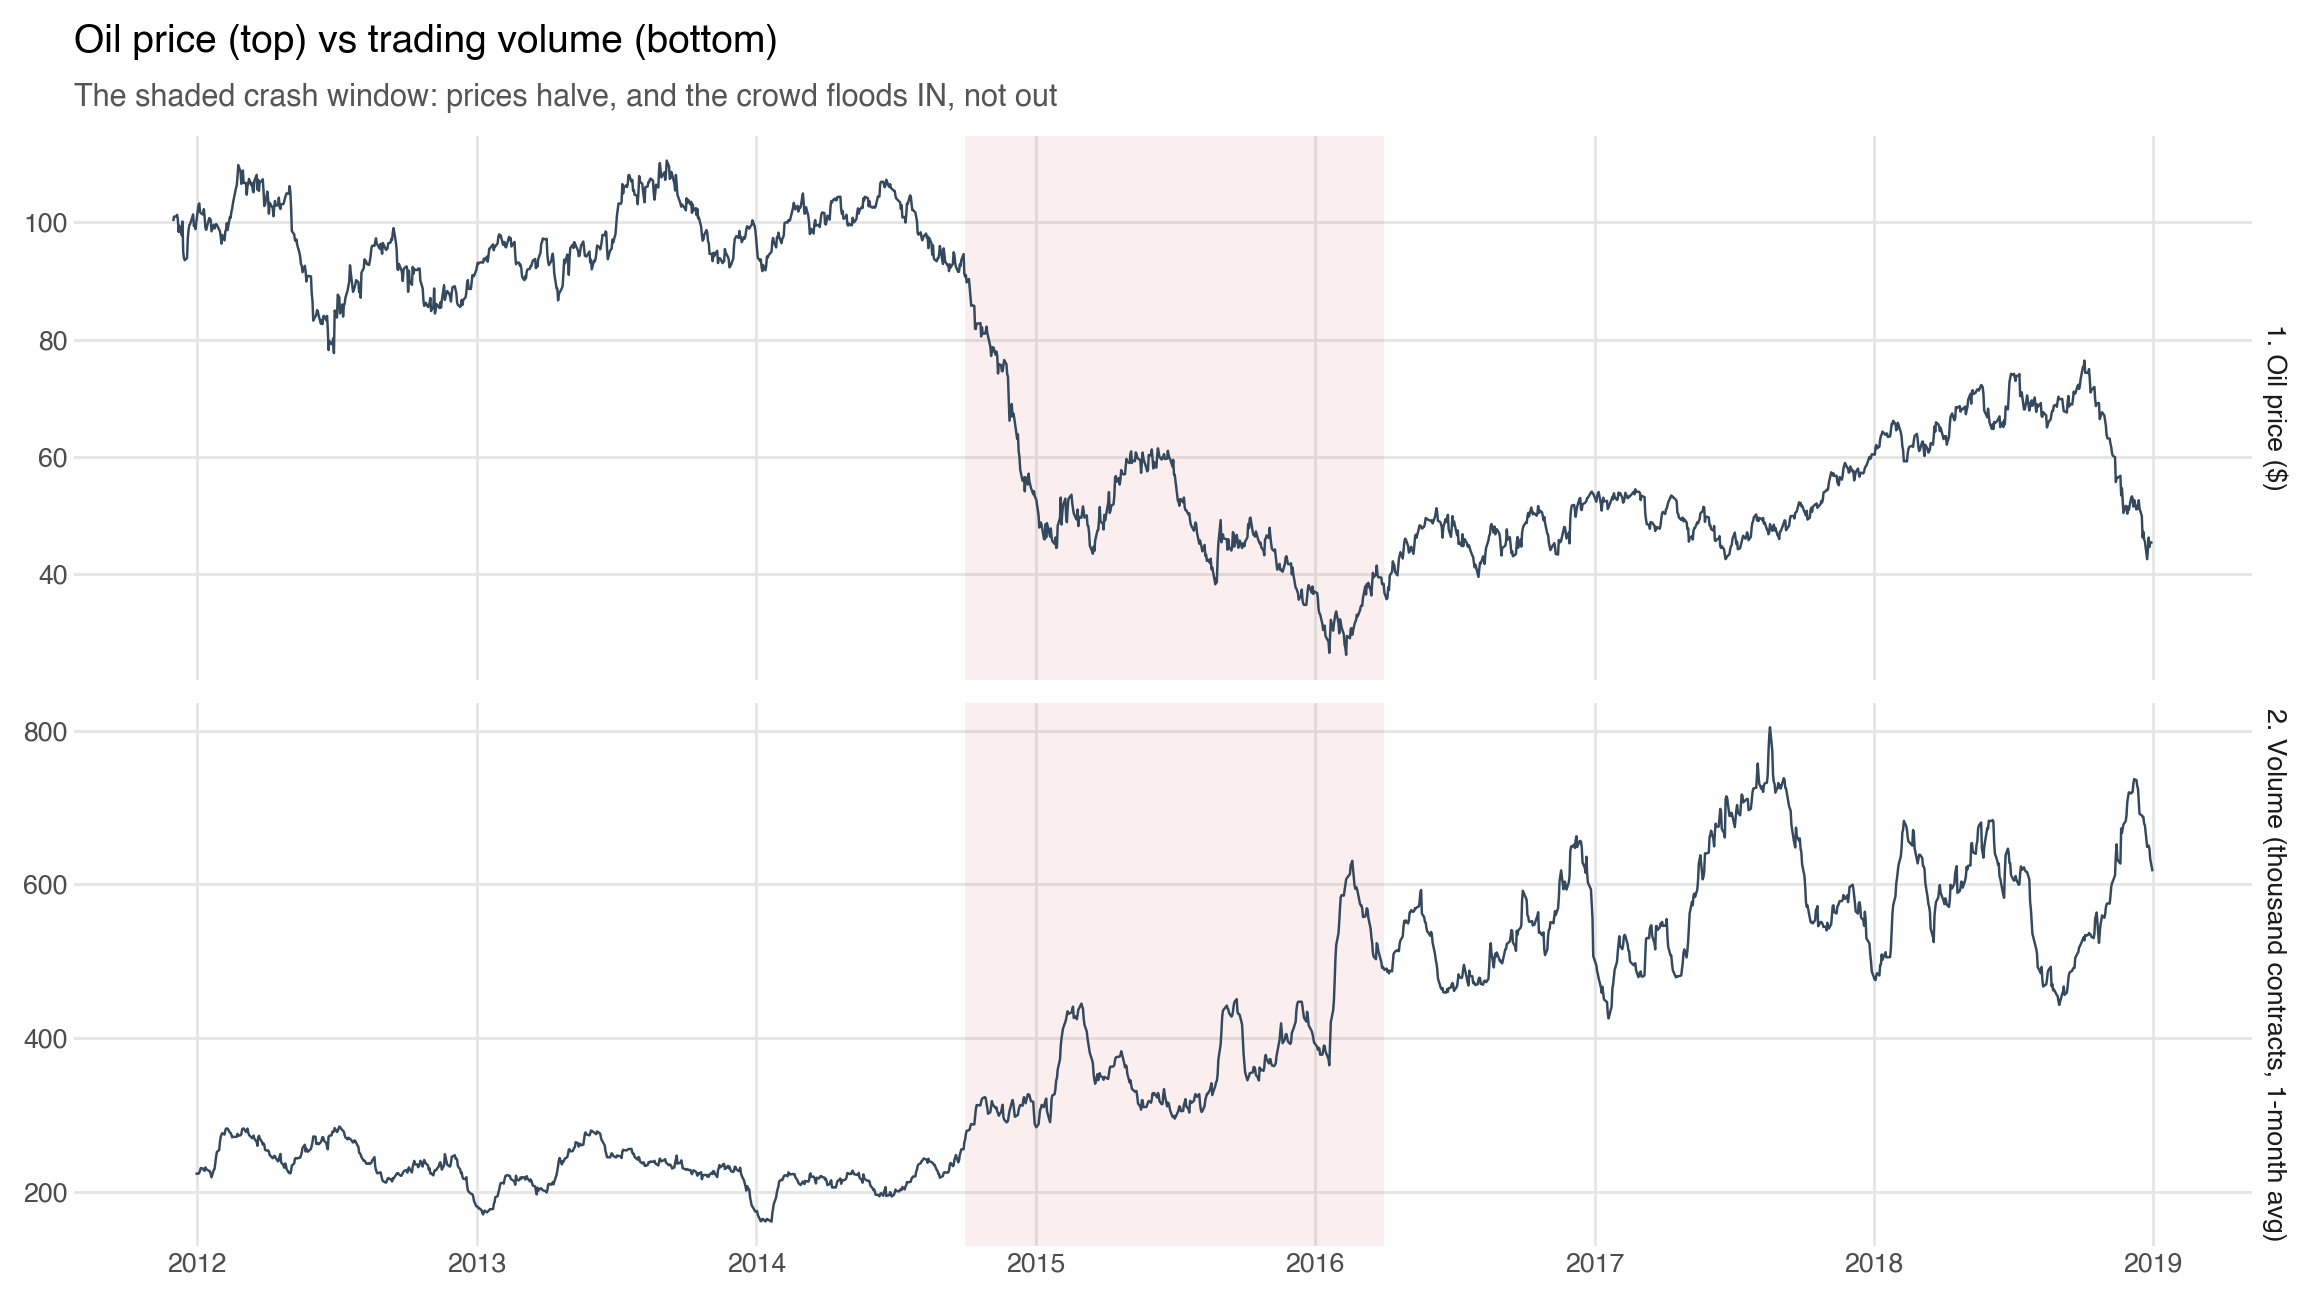

In [22]:
vol = oil.dropna(subset=['Volume']).copy()
vol['SmoothVol'] = vol.Volume.rolling(21).mean()/1000
pan = pd.concat([
    pd.DataFrame({'Date': vol.Date, 'v': vol.Price, 'Panel': '1. Oil price ($)'}),
    pd.DataFrame({'Date': vol.Date, 'v': vol.SmoothVol, 'Panel': '2. Volume (thousand contracts, 1-month avg)'})])

(ggplot(pan, aes('Date', 'v')) +
 annotate('rect', xmin=pd.Timestamp('2014-10-01'), xmax=pd.Timestamp('2016-04-01'),
          ymin=-np.inf, ymax=np.inf, fill='#C0392B', alpha=0.08) +
 geom_line(color='#34495E', size=0.5) +
 facet_grid('Panel ~ .', scales='free_y') +
 scale_x_datetime(date_breaks='1 year', date_labels='%Y') +
 labs(title='Oil price (top) vs trading volume (bottom)',
      subtitle='The shaded crash window: prices halve, and the crowd floods IN, not out',
      x='', y='') +
 gg_theme(11.5, 6.5))

In [23]:
pre   = vol[vol.Date <  '2014-07-01'].Volume.mean()
crash = vol[(vol.Date >= '2014-10-01') & (vol.Date < '2016-04-01')].Volume.mean()
print(f'Average daily volume before the crash : {pre:,.0f} contracts')
print(f'Average daily volume during the crash : {crash:,.0f} contracts   ({crash/pre-1:+.0%})')

Average daily volume before the crash : 231,256 contracts
Average daily volume during the crash : 383,473 contracts   (+66%)


---
## Monthly seasonality


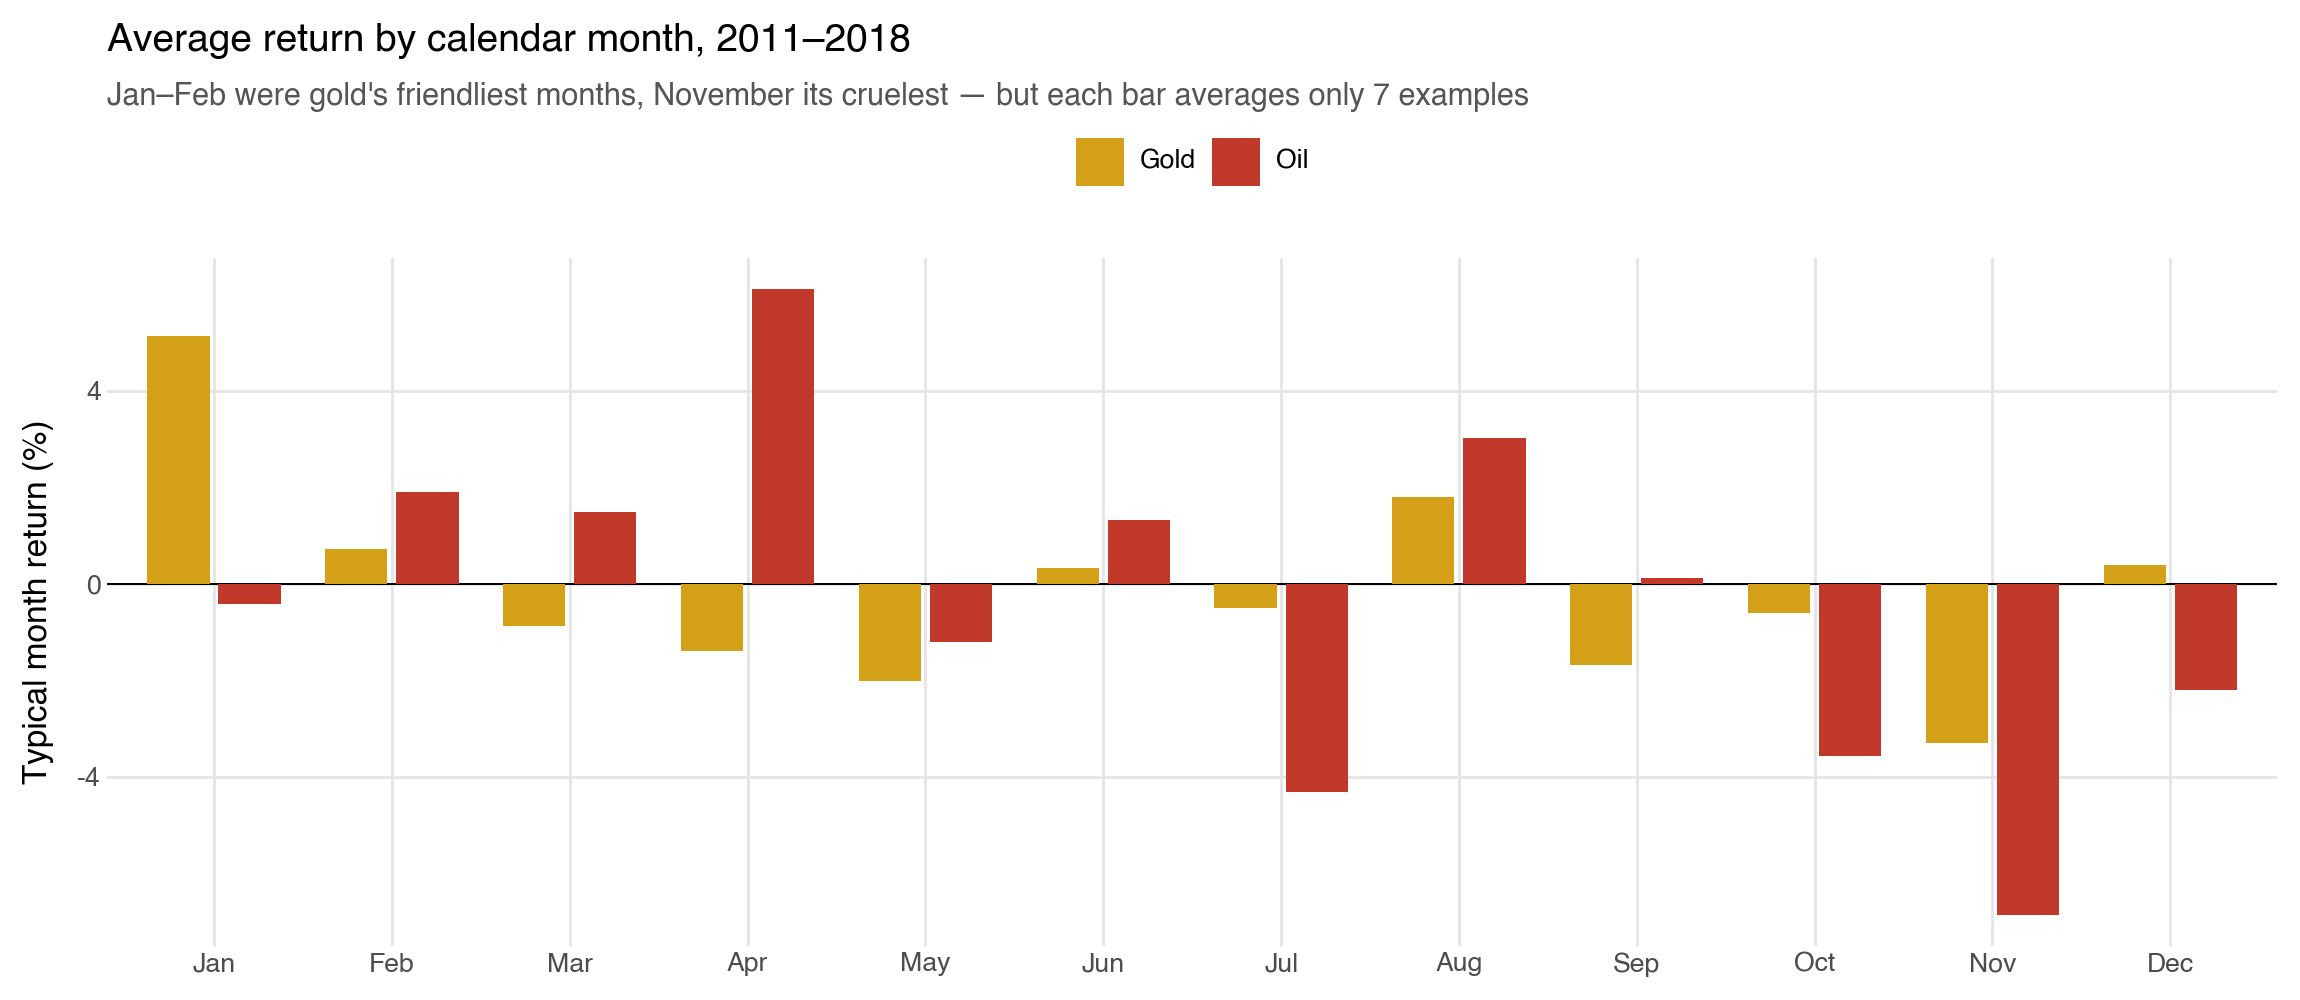

In [24]:
mr = merged.set_index('Date')[['Close','Oil']].pct_change().dropna()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
mavg = (mr.groupby(mr.index.month).mean()*21*100).rename(columns={'Close':'Gold','Oil':'Oil'})
ml = mavg.reset_index(names='m').melt('m', var_name='Asset', value_name='Return')
ml['Month'] = pd.Categorical([months[m-1] for m in ml.m], categories=months)

(ggplot(ml, aes('Month', 'Return', fill='Asset')) +
 geom_hline(yintercept=0, color='black', size=0.4) +
 geom_col(position=position_dodge(0.8), width=0.7) +
 scale_fill_manual(values=PALETTE) +
 labs(title='Average return by calendar month, 2011–2018',
      subtitle='Jan–Feb were gold\'s friendliest months, November its cruelest — but each bar averages only 7 examples',
      x='', y='Typical month return (%)') +
 gg_theme(11.5, 5))